# Descriptive spatiotemporal analytics of Chicago taxi demand

In this notebook we analyze the full processed dataset: start times, trip duration and distance, origins and destinations, prices, and idle time, each at several spatial and temporal resolutions.

## Method notes

A few things to keep in mind while reading. DuckDB scans the Parquet with its 13+ million trips lazily, only aggregated results end up in pandas. For the spatial comparison we use census tracts plus H3 resolutions 7, 8 and 9 (approximate cell diameters are printed below). The published taxi coordinates are privacy protected area centroids, not exact pickup points, so H3 resolution 9 gives finer bins but not finer true positional accuracy. Temporal comparison uses 15 minute, hourly, 4 hourly and daily bins.

For trip duration we rely on `trip_seconds`. The published timestamps are rounded to 15 minutes, which we audit separately. Idle time is estimated from consecutive records of the same anonymized taxi; gaps outside 0 to 12 hours are treated as off shift or missing observations rather than real idle time.

In [1]:
from pathlib import Path

import duckdb
import geopandas as gpd
import h3
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from shapely.geometry import LineString, Polygon

from run_config import PATHS, PROJECT_ROOT

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)

GOLD = PATHS.gold_taxi_trips.as_posix()
SILVER = PATHS.silver_taxi_trips.as_posix()
BRONZE = PATHS.bronze_taxi_trips.as_posix()
for path in (GOLD, SILVER, BRONZE):
    if not Path(path).exists():
        raise FileNotFoundError(path)

con = duckdb.connect()
con.execute("SET threads = 4")
con.execute(f"CREATE OR REPLACE VIEW trips AS SELECT * FROM read_parquet('{GOLD}')")

## 1. Coverage and overall trip profile

In [2]:
coverage = con.sql("""
SELECT
    COUNT(*) AS trips,
    COUNT(DISTINCT taxi_id) AS taxis,
    MIN(trip_start_timestamp) AS first_trip,
    MAX(trip_start_timestamp) AS last_trip,
    COUNT(DISTINCT CAST(trip_start_timestamp AS DATE)) AS active_days,
    ROUND(AVG(trip_miles), 2) AS mean_miles,
    ROUND(MEDIAN(trip_miles), 2) AS median_miles,
    ROUND(AVG(trip_seconds) / 60, 2) AS mean_minutes,
    ROUND(MEDIAN(trip_seconds) / 60, 2) AS median_minutes,
    ROUND(AVG(fare), 2) AS mean_fare,
    ROUND(MEDIAN(fare), 2) AS median_fare
FROM trips
""").df()
display(coverage)

,trips,taxis,first_trip,last_trip,active_days,mean_miles,median_miles,mean_minutes,median_minutes,mean_fare,median_fare
0,13387586,3313,2024-01-01,2026-05-01,852,7.15,3.91,21.06,16.05,22.08,15.25


## 2. Timestamp rounding and invalid ordering

We test all pipeline layers here. Rounding can make the displayed start and end of a short trip equal, and the duration computed from timestamps can differ from `trip_seconds` by a few minutes. What rounding cannot explain are the extreme negative intervals we saw in corrupt raw records, so those are a separate issue.

In [3]:
layer_paths = {"bronze": BRONZE, "silver": SILVER, "gold": GOLD}
audit_rows = []
for layer, path in layer_paths.items():
    row = con.execute(f"""
        SELECT
            COUNT(*) AS rows,
            COUNT(*) FILTER (WHERE trip_end_timestamp < trip_start_timestamp) AS end_before_start,
            COUNT(*) FILTER (WHERE trip_end_timestamp = trip_start_timestamp) AS equal_timestamps,
            COUNT(*) FILTER (WHERE trip_seconds IS NULL) AS missing_trip_seconds
        FROM read_parquet('{path}')
    """).fetchone()
    audit_rows.append((layer, *row))

timestamp_audit = pd.DataFrame(audit_rows, columns=[
    "layer", "rows", "end_before_start", "equal_timestamps", "missing_trip_seconds"
]).set_index("layer")
display(timestamp_audit)

minute_grid = con.sql("""
SELECT
    EXTRACT(minute FROM trip_start_timestamp)::INTEGER AS minute,
    COUNT(*) AS trips
FROM trips GROUP BY 1 ORDER BY 1
""").df()
display(minute_grid)

duration_agreement = con.sql("""
SELECT
    ROUND(AVG(ABS(EPOCH(trip_end_timestamp - trip_start_timestamp) - trip_seconds)), 1) AS mean_absolute_error_seconds,
    MEDIAN(EPOCH(trip_end_timestamp - trip_start_timestamp) - trip_seconds) AS median_error_seconds,
    QUANTILE_CONT(EPOCH(trip_end_timestamp - trip_start_timestamp) - trip_seconds, [0.01, 0.99]) AS error_p01_p99_seconds
FROM trips
""").df()
display(duration_agreement)

,rows,end_before_start,equal_timestamps,missing_trip_seconds
layer,,,,
bronze,15406960,100,3796019,2936
silver,13387587,0,2597942,0
gold,13387586,0,2597942,0


,minute,trips
0,0,3363972
1,15,3326785
2,30,3327706
3,45,3369123


,mean_absolute_error_seconds,median_error_seconds,error_p01_p99_seconds
0,320.7,5.0,"[-766.0, 756.0]"


## 3. Demand and trip characteristics over time

The assignment asks how start time, trip length, duration and price vary over time. All of these variables are heavily right skewed: a small number of airport and long distance trips pulls the mean far above what a typical trip looks like. We therefore always report the median (the typical trip), the interquartile range (the middle 50%) and the 95th and 99th percentiles (the tail) next to the mean.

Hourly profiles keep the daily detail. Four hour periods give a coarser but more stable picture for business interpretation. Neither view replaces the other.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,trips,mean_miles,median_miles,p25_miles,p75_miles,p95_miles,p99_miles,mean_minutes,median_minutes,p25_minutes,p75_minutes,p95_minutes,p99_minutes,mean_fare,median_fare,p25_fare,p75_fare,p95_fare,p99_fare,mean_total,median_total
0,13387586,7.15,3.91,1.41,12.24,18.41,26.81,21.06,16.05,9.0,28.47,53.57,75.0,22.08,15.25,8.54,33.5,49.5,70.0,27.14,17.81


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

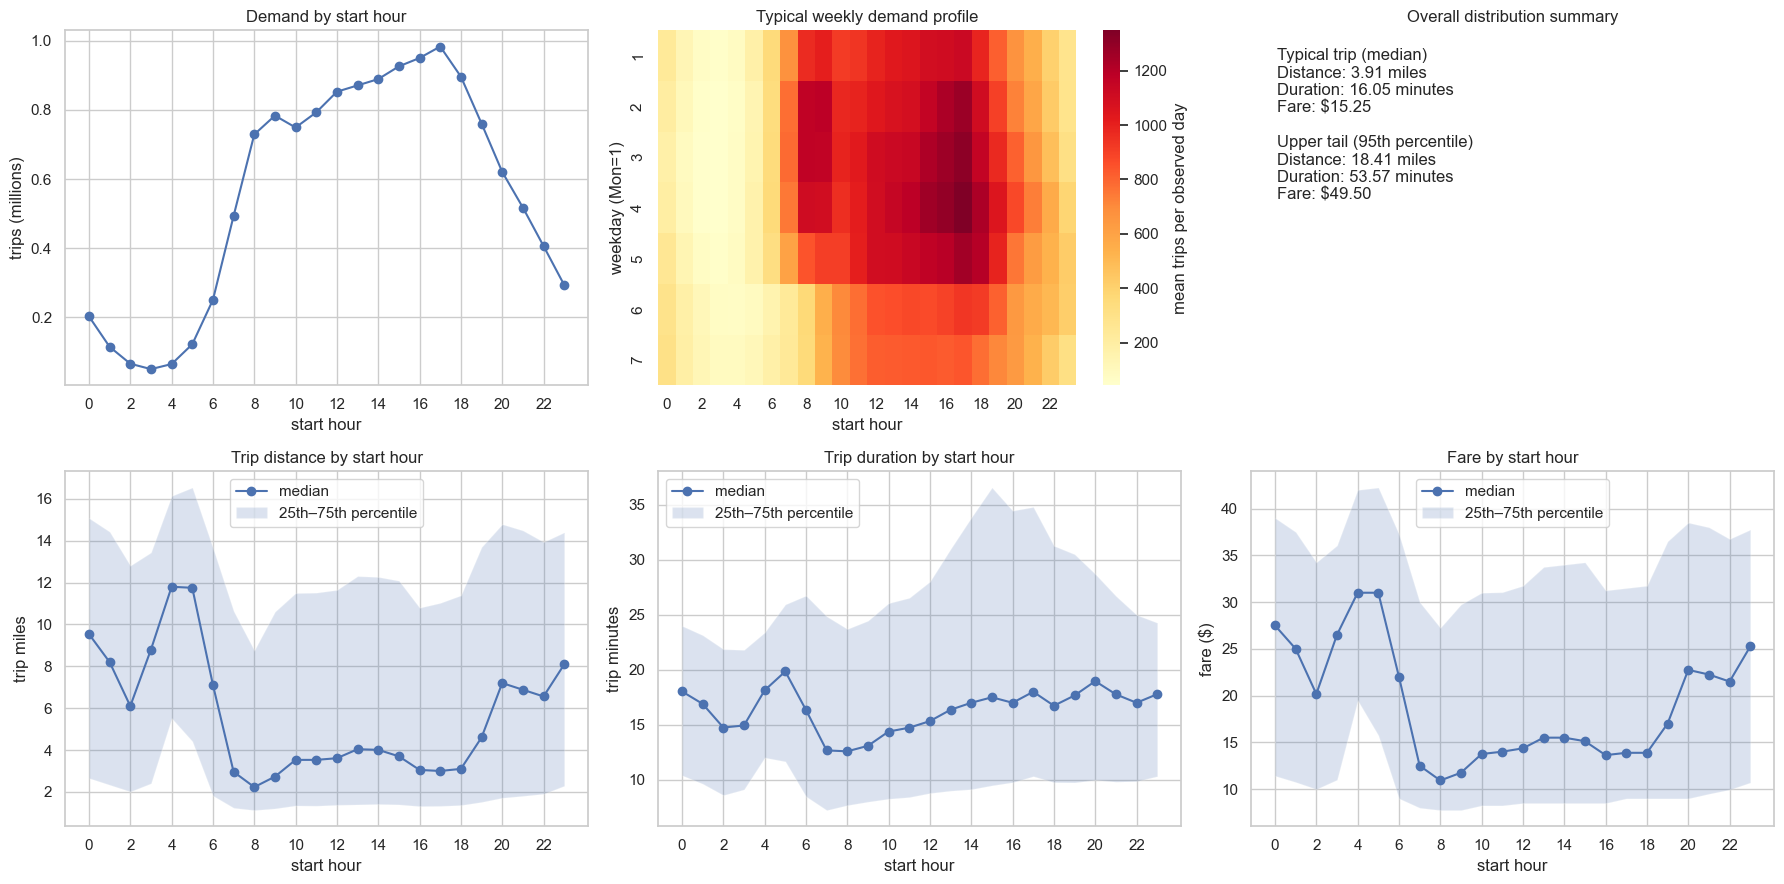

,start_hour,trips,mean_miles,median_miles,p25_miles,p75_miles,mean_minutes,median_minutes,p25_minutes,p75_minutes,mean_fare,median_fare,p25_fare,p75_fare,median_total
0,0,202690,9.54,9.54,2.66,15.08,18.28,18.03,10.40,24.00,26.92,27.50,11.42,39.00,30.50
1,1,114728,9.11,8.20,2.34,14.43,17.48,16.90,9.63,23.15,26.01,25.00,10.75,37.50,29.25
2,2,65847,8.24,6.10,2.02,12.81,16.23,14.75,8.60,21.88,24.28,20.17,10.00,34.25,23.93
3,3,50202,9.19,8.80,2.41,13.44,16.52,14.93,9.12,21.82,26.94,26.50,11.00,36.06,28.00
4,4,64828,11.38,11.80,5.52,16.14,18.60,18.13,12.02,23.40,31.90,31.00,19.49,42.00,32.10
5,5,122144,11.00,11.75,4.42,16.54,20.11,19.85,11.67,25.95,30.45,31.00,15.75,42.25,32.50
6,6,250657,8.45,7.11,1.82,13.65,19.72,16.35,8.48,26.75,24.77,22.00,9.00,37.25,24.00
7,7,493416,6.22,2.96,1.24,10.64,18.93,12.67,7.23,24.87,20.05,12.50,8.00,30.00,14.55
8,8,729091,5.49,2.23,1.13,8.76,18.34,12.58,7.68,23.72,18.45,10.92,7.75,27.25,13.05
9,9,783600,6.14,2.73,1.21,10.61,18.37,13.08,8.00,24.47,19.47,11.75,7.75,29.75,14.00


In [4]:
overall_trip_distribution = con.sql("""
SELECT
    COUNT(*) AS trips,
    ROUND(AVG(trip_miles), 2) AS mean_miles,
    ROUND(MEDIAN(trip_miles), 2) AS median_miles,
    ROUND(QUANTILE_CONT(trip_miles, .25), 2) AS p25_miles,
    ROUND(QUANTILE_CONT(trip_miles, .75), 2) AS p75_miles,
    ROUND(QUANTILE_CONT(trip_miles, .95), 2) AS p95_miles,
    ROUND(QUANTILE_CONT(trip_miles, .99), 2) AS p99_miles,
    ROUND(AVG(trip_seconds) / 60, 2) AS mean_minutes,
    ROUND(MEDIAN(trip_seconds) / 60, 2) AS median_minutes,
    ROUND(QUANTILE_CONT(trip_seconds, .25) / 60, 2) AS p25_minutes,
    ROUND(QUANTILE_CONT(trip_seconds, .75) / 60, 2) AS p75_minutes,
    ROUND(QUANTILE_CONT(trip_seconds, .95) / 60, 2) AS p95_minutes,
    ROUND(QUANTILE_CONT(trip_seconds, .99) / 60, 2) AS p99_minutes,
    ROUND(AVG(fare), 2) AS mean_fare,
    ROUND(MEDIAN(fare), 2) AS median_fare,
    ROUND(QUANTILE_CONT(fare, .25), 2) AS p25_fare,
    ROUND(QUANTILE_CONT(fare, .75), 2) AS p75_fare,
    ROUND(QUANTILE_CONT(fare, .95), 2) AS p95_fare,
    ROUND(QUANTILE_CONT(fare, .99), 2) AS p99_fare,
    ROUND(AVG(trip_total), 2) AS mean_total,
    ROUND(MEDIAN(trip_total), 2) AS median_total
FROM trips
""").df()
display(overall_trip_distribution)

hourly_profile = con.sql("""
SELECT
    EXTRACT(hour FROM trip_start_timestamp)::INTEGER AS start_hour,
    COUNT(*) AS trips,
    AVG(trip_miles) AS mean_miles,
    MEDIAN(trip_miles) AS median_miles,
    QUANTILE_CONT(trip_miles, .25) AS p25_miles,
    QUANTILE_CONT(trip_miles, .75) AS p75_miles,
    AVG(trip_seconds) / 60 AS mean_minutes,
    MEDIAN(trip_seconds) / 60 AS median_minutes,
    QUANTILE_CONT(trip_seconds, .25) / 60 AS p25_minutes,
    QUANTILE_CONT(trip_seconds, .75) / 60 AS p75_minutes,
    AVG(fare) AS mean_fare,
    MEDIAN(fare) AS median_fare,
    QUANTILE_CONT(fare, .25) AS p25_fare,
    QUANTILE_CONT(fare, .75) AS p75_fare,
    MEDIAN(trip_total) AS median_total
FROM trips
GROUP BY 1
ORDER BY 1
""").df()

weekly_profile = con.sql("""
SELECT
    EXTRACT(isodow FROM trip_start_timestamp)::INTEGER AS weekday,
    EXTRACT(hour FROM trip_start_timestamp)::INTEGER AS start_hour,
    COUNT(*) / COUNT(DISTINCT CAST(trip_start_timestamp AS DATE))::DOUBLE
        AS mean_trips_per_observed_day
FROM trips
GROUP BY 1, 2
ORDER BY 1, 2
""").df()

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes[0, 0].plot(hourly_profile.start_hour, hourly_profile.trips / 1e6, marker="o")
axes[0, 0].set(
    title="Demand by start hour", xlabel="start hour", ylabel="trips (millions)",
    xticks=range(0, 24, 2),
)

weekly_heat = weekly_profile.pivot(
    index="weekday", columns="start_hour", values="mean_trips_per_observed_day"
)
sns.heatmap(
    weekly_heat, cmap="YlOrRd", ax=axes[0, 1],
    cbar_kws={"label": "mean trips per observed day"},
)
axes[0, 1].set(title="Typical weekly demand profile", xlabel="start hour", ylabel="weekday (Mon=1)")

axes[0, 2].axis("off")
summary_text = (
    f"Typical trip (median)\n"
    f"Distance: {overall_trip_distribution.at[0, 'median_miles']:.2f} miles\n"
    f"Duration: {overall_trip_distribution.at[0, 'median_minutes']:.2f} minutes\n"
    f"Fare: ${overall_trip_distribution.at[0, 'median_fare']:.2f}\n\n"
    f"Upper tail (95th percentile)\n"
    f"Distance: {overall_trip_distribution.at[0, 'p95_miles']:.2f} miles\n"
    f"Duration: {overall_trip_distribution.at[0, 'p95_minutes']:.2f} minutes\n"
    f"Fare: ${overall_trip_distribution.at[0, 'p95_fare']:.2f}"
)
axes[0, 2].text(0.05, 0.95, summary_text, va="top", fontsize=12)
axes[0, 2].set_title("Overall distribution summary")

for ax, median_col, low_col, high_col, ylabel, title in [
    (axes[1, 0], "median_miles", "p25_miles", "p75_miles", "trip miles", "Trip distance by start hour"),
    (axes[1, 1], "median_minutes", "p25_minutes", "p75_minutes", "trip minutes", "Trip duration by start hour"),
    (axes[1, 2], "median_fare", "p25_fare", "p75_fare", "fare ($)", "Fare by start hour"),
]:
    ax.plot(hourly_profile.start_hour, hourly_profile[median_col], marker="o", label="median")
    ax.fill_between(
        hourly_profile.start_hour,
        hourly_profile[low_col], hourly_profile[high_col],
        alpha=.2, label="25th–75th percentile",
    )
    ax.set(title=title, xlabel="start hour", ylabel=ylabel, xticks=range(0, 24, 2))
    ax.legend()

plt.tight_layout()
plt.show()
display(hourly_profile.round(2))

### What the hourly profiles show

The mean is above the median for distance, duration and fare, which confirms the skew. Total activity concentrates from midday into the early evening, with the single busiest start hour around 17:00. Trips that start late at night or in the very early morning are typically longer and more expensive than daytime trips; a plausible explanation is a larger share of airport and cross city journeys, but that is a hypothesis we check spatially later, not a conclusion. Median duration stays elevated around the evening peak even though median distance is comparatively short there. This is consistent with congestion, but it may also reflect a different mixture of origins, destinations and trip purposes; the OD-controlled comparison below separates part of that composition effect. And within every single hour the interquartile bands stay wide: time of day alone does not determine what a trip looks like, origin, destination, traffic and purpose matter as well.

,period,trips,trip_share_pct,median_miles,median_minutes,median_fare,median_total
0,00:00–03:59,433467,3.24,8.56,16.95,25.75,29.00
1,04:00–07:59,931045,6.95,5.48,15.07,18.76,20.75
2,08:00–11:59,3054940,22.82,2.97,13.67,12.50,14.59
3,12:00–15:59,3539129,26.44,3.83,16.55,15.01,17.30
4,16:00–19:59,3590731,26.82,3.26,17.30,14.25,16.78
5,20:00–23:59,1838274,13.73,7.10,17.97,22.75,26.50


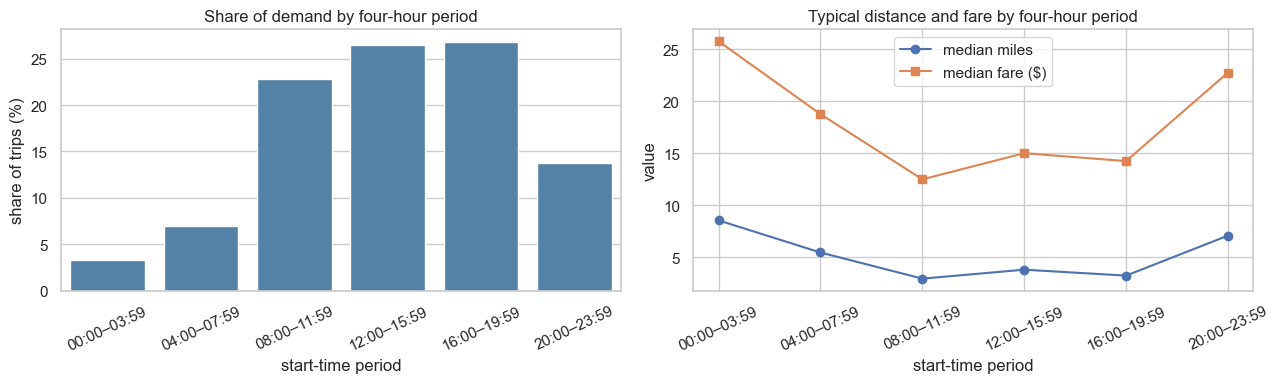

In [5]:
four_hour_profile = con.sql("""
SELECT
    FLOOR(EXTRACT(hour FROM trip_start_timestamp) / 4)::INTEGER * 4 AS period_start_hour,
    COUNT(*) AS trips,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS trip_share_pct,
    ROUND(MEDIAN(trip_miles), 2) AS median_miles,
    ROUND(MEDIAN(trip_seconds) / 60, 2) AS median_minutes,
    ROUND(MEDIAN(fare), 2) AS median_fare,
    ROUND(MEDIAN(trip_total), 2) AS median_total
FROM trips
GROUP BY 1
ORDER BY 1
""").df()
four_hour_profile["period"] = four_hour_profile.period_start_hour.map(
    lambda hour: f"{hour:02d}:00–{hour + 3:02d}:59"
)
display(four_hour_profile[[
    "period", "trips", "trip_share_pct", "median_miles",
    "median_minutes", "median_fare", "median_total",
]])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(data=four_hour_profile, x="period", y="trip_share_pct", color="steelblue", ax=axes[0])
axes[0].set(title="Share of demand by four-hour period", xlabel="start-time period", ylabel="share of trips (%)")
axes[0].tick_params(axis="x", rotation=25)

axes[1].plot(four_hour_profile.period, four_hour_profile.median_miles, marker="o", label="median miles")
axes[1].plot(four_hour_profile.period, four_hour_profile.median_fare, marker="s", label="median fare ($)")
axes[1].set(title="Typical distance and fare by four-hour period", xlabel="start-time period", ylabel="value")
axes[1].tick_params(axis="x", rotation=25)
axes[1].legend()
plt.tight_layout()
plt.show()

### What changes at four hour resolution?

Aggregating to four hour periods removes most of the noise and produces operating periods that are easy to communicate. In this data the periods from 12:00 to 15:59 and from 16:00 to 19:59 together account for more than half of all trips. Night and late evening periods have lower demand but higher typical distance and fare.

This is the resolution trade off from the lecture: coarse temporal units give stable tactical patterns, fine units reveal the precise peaks needed for dispatching. So we show both instead of declaring one resolution correct.

## 4. Effect of temporal bin size

Short bins reveal peaks but have higher relative variability; long bins smooth local surges. The coefficient of variation (CV) makes variability comparable across bin sizes with different mean counts.

,bins,mean,median,p95,cv
bin_size,,,,,
15 minutes,81685,163.89,167.0,340.00,0.67
1 hour,20422,655.55,676.0,1347.95,0.66
4 hours,5107,2621.42,2430.0,5215.70,0.63
1 day,852,15713.13,16127.5,20958.90,0.23


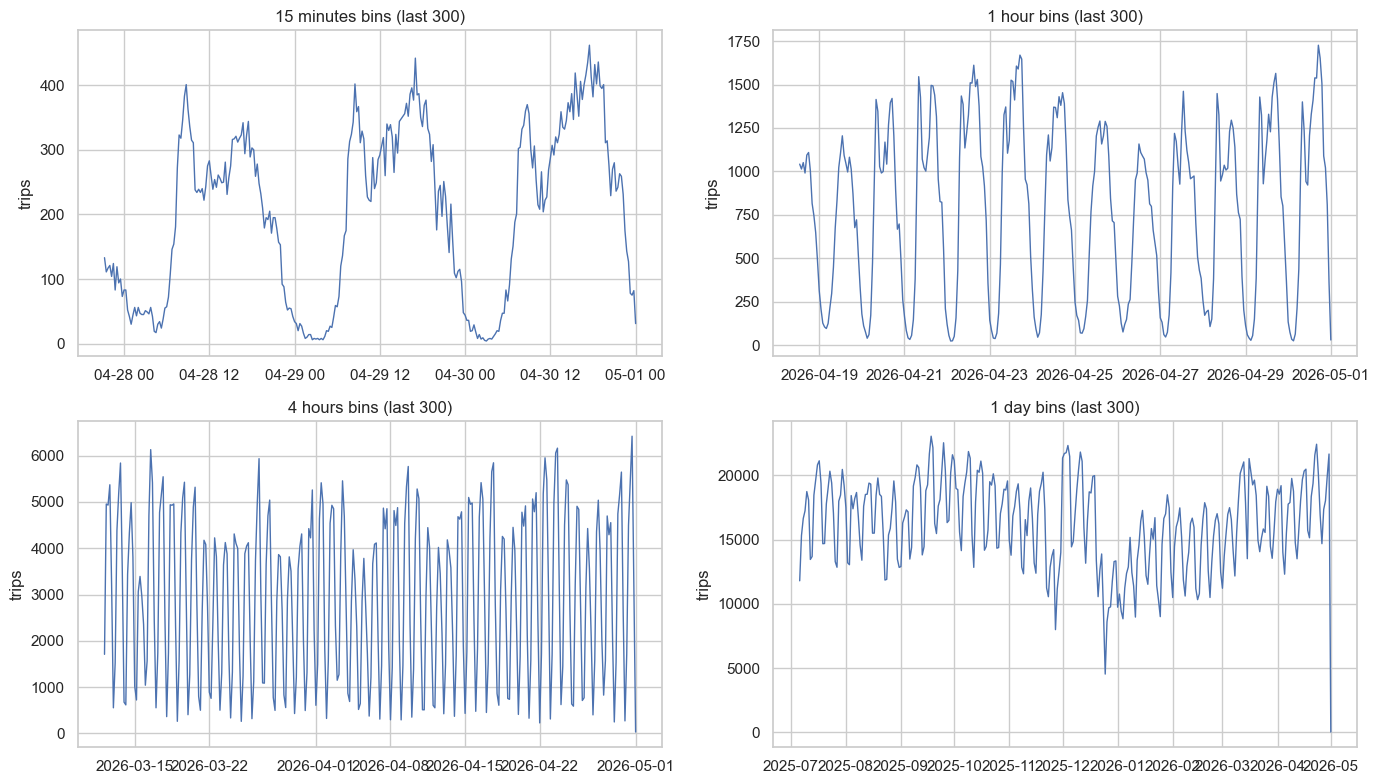

In [6]:
intervals = {"15 minutes": "15 minutes", "1 hour": "1 hour", "4 hours": "4 hours", "1 day": "1 day"}
bin_rows, bin_series = [], {}
for label, interval in intervals.items():
    values = con.execute(f"""
        SELECT TIME_BUCKET(INTERVAL '{interval}', trip_start_timestamp) AS time_bin, COUNT(*) AS trips
        FROM trips GROUP BY 1 ORDER BY 1
    """).df()
    bin_series[label] = values
    bin_rows.append({
        "bin_size": label, "bins": len(values), "mean": values.trips.mean(),
        "median": values.trips.median(), "p95": values.trips.quantile(.95),
        "cv": values.trips.std() / values.trips.mean()
    })
bin_summary = pd.DataFrame(bin_rows).set_index("bin_size")
display(bin_summary.round(2))

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, (label, values) in zip(axes.flat, bin_series.items()):
    sample = values.tail(min(len(values), 300))
    ax.plot(sample.time_bin, sample.trips, linewidth=1)
    ax.set_title(f"{label} bins (last {len(sample)})")
    ax.set_ylabel("trips")
plt.tight_layout(); plt.show()

## 5. Origin, destination, and spatial resolution

The H3 comparisons at resolutions 7, 8 and 9 use the published pickup centroid. Census tracts follow administrative boundaries and vary in size; H3 cells are uniform hexagons, which reduces shape and area effects but does not make the Modifiable Areal Unit Problem (MAUP) go away.

,all_trips,pickup_area_mapped,dropoff_area_mapped,pickup_mapped_pct,dropoff_mapped_pct
0,13387586,13387586,12376680,100.0,92.45


,area,community_name,pickups,pickup_share_pct,dropoffs,dropoff_share_pct,pickup_median_miles,pickup_median_minutes,pickup_median_fare
7,8,Near North Side,3058058,22.84,3298862,26.65,1.64,10.53,9.50
75,76,Ohare,2859934,21.36,533297,4.31,16.31,33.42,42.00
31,32,Loop,2228460,16.65,2294039,18.54,1.47,9.82,8.75
27,28,Near West Side,1376754,10.28,1355378,10.95,1.73,11.00,9.25
32,33,Near South Side,471863,3.52,523369,4.23,2.95,15.43,13.25
5,6,Lake View,457732,3.42,605785,4.89,4.10,15.28,15.00
55,56,Garfield Ridge,389414,2.91,136749,1.10,12.39,28.65,33.75
6,7,Lincoln Park,301518,2.25,556135,4.49,2.86,13.98,12.20
2,3,Uptown,226153,1.69,247706,2.00,5.41,16.83,18.00
76,77,Edgewater,156722,1.17,200121,1.62,6.57,18.37,20.25


,all_trips,trips_with_dropoff_h3,missing_dropoff_h3,missing_pct
0,13387586,12447158,940428,7.02


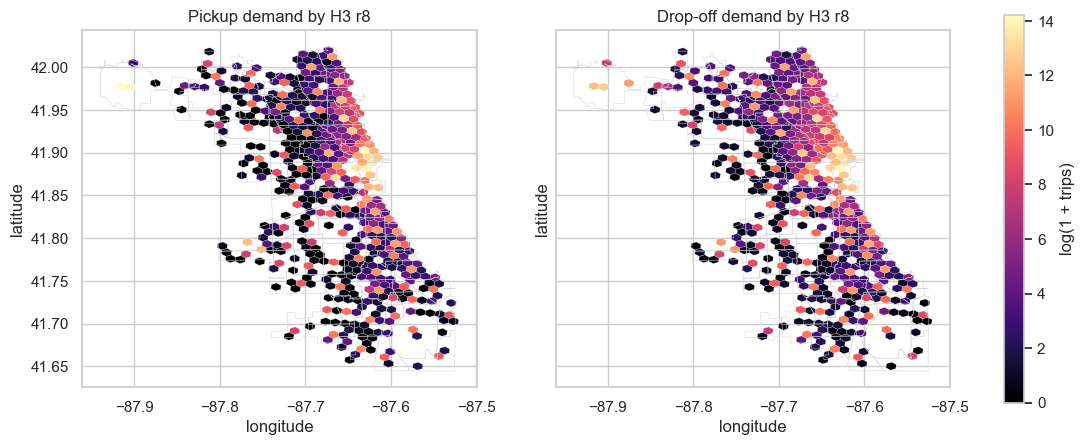

In [7]:
community_areas = gpd.read_parquet(PATHS.silver_community_areas)
community_areas["area"] = pd.to_numeric(
    community_areas["AREA_NUM_1"], errors="coerce"
).astype("Int64")
community_areas["community_name"] = community_areas["COMMUNITY"].str.title()
community_names = community_areas[["area", "community_name"]].drop_duplicates()

community_coverage = con.sql("""
SELECT
    COUNT(*) AS all_trips,
    COUNT(pickup_community_area) AS pickup_area_mapped,
    COUNT(dropoff_community_area) AS dropoff_area_mapped,
    ROUND(100.0 * COUNT(pickup_community_area) / COUNT(*), 2) AS pickup_mapped_pct,
    ROUND(100.0 * COUNT(dropoff_community_area) / COUNT(*), 2) AS dropoff_mapped_pct
FROM trips
""").df()
display(community_coverage)

community_summary = con.sql("""
WITH pickup AS (
    SELECT pickup_community_area::INTEGER AS area,
           COUNT(*) AS pickups,
           MEDIAN(trip_miles) AS pickup_median_miles,
           MEDIAN(trip_seconds) / 60 AS pickup_median_minutes,
           MEDIAN(fare) AS pickup_median_fare
    FROM trips
    WHERE pickup_community_area IS NOT NULL
    GROUP BY 1
), dropoff AS (
    SELECT dropoff_community_area::INTEGER AS area, COUNT(*) AS dropoffs
    FROM trips
    WHERE dropoff_community_area IS NOT NULL
    GROUP BY 1
)
SELECT COALESCE(p.area, d.area) AS area,
       COALESCE(p.pickups, 0) AS pickups,
       COALESCE(d.dropoffs, 0) AS dropoffs,
       p.pickup_median_miles, p.pickup_median_minutes, p.pickup_median_fare
FROM pickup p
FULL OUTER JOIN dropoff d ON p.area = d.area
""").df().merge(community_names, on="area", how="left")
community_summary["pickup_share_pct"] = 100 * community_summary.pickups / community_summary.pickups.sum()
community_summary["dropoff_share_pct"] = 100 * community_summary.dropoffs / community_summary.dropoffs.sum()
display(
    community_summary.sort_values("pickups", ascending=False)[[
        "area", "community_name", "pickups", "pickup_share_pct",
        "dropoffs", "dropoff_share_pct", "pickup_median_miles",
        "pickup_median_minutes", "pickup_median_fare",
    ]].head(15).round(2)
)

locations = con.sql("""
SELECT
    pickup_centroid_location AS location_id,
    pickup_centroid_latitude AS lat,
    pickup_centroid_longitude AS lon,
    pickup_census_tract AS census_tract,
    pickup_h3_cell AS h3_8,
    COUNT(*) AS trips,
    AVG(trip_miles) AS mean_miles,
    AVG(fare) AS mean_fare
FROM trips
WHERE pickup_centroid_latitude IS NOT NULL
  AND pickup_centroid_longitude IS NOT NULL
  AND pickup_h3_cell IS NOT NULL
GROUP BY 1, 2, 3, 4, 5
""").df()
locations["h3_7"] = locations.h3_8.map(lambda cell: h3.cell_to_parent(cell, 7))
locations["h3_9"] = [
    h3.latlng_to_cell(lat, lon, 9) for lat, lon in zip(locations.lat, locations.lon)
]

destinations = con.sql("""
SELECT
    dropoff_centroid_latitude AS lat,
    dropoff_centroid_longitude AS lon,
    dropoff_h3_cell AS h3_8,
    COUNT(*) AS trips
FROM trips
WHERE dropoff_centroid_latitude IS NOT NULL
  AND dropoff_centroid_longitude IS NOT NULL
  AND dropoff_h3_cell IS NOT NULL
GROUP BY 1, 2, 3
""").df()
destinations["h3_7"] = destinations.h3_8.map(lambda cell: h3.cell_to_parent(cell, 7))
destinations["h3_9"] = [
    h3.latlng_to_cell(lat, lon, 9) for lat, lon in zip(destinations.lat, destinations.lon)
]

dropoff_coverage = con.sql("""
SELECT
    COUNT(*) AS all_trips,
    COUNT(dropoff_h3_cell) AS trips_with_dropoff_h3,
    COUNT(*) - COUNT(dropoff_h3_cell) AS missing_dropoff_h3,
    ROUND(100.0 * (COUNT(*) - COUNT(dropoff_h3_cell)) / COUNT(*), 2) AS missing_pct
FROM trips
""").df()
display(dropoff_coverage)

def h3_geometry(cell):
    return Polygon([(lng, lat) for lat, lng in h3.cell_to_boundary(cell)])

pickup_h3 = (
    locations.groupby("h3_8", as_index=False).trips.sum()
    .rename(columns={"h3_8": "h3_cell", "trips": "pickup_trips"})
)
dropoff_h3 = (
    destinations.groupby("h3_8", as_index=False).trips.sum()
    .rename(columns={"h3_8": "h3_cell", "trips": "dropoff_trips"})
)
h3_demand = pickup_h3.merge(dropoff_h3, on="h3_cell", how="outer").fillna(0)
h3_demand = gpd.GeoDataFrame(
    h3_demand,
    geometry=h3_demand.h3_cell.map(h3_geometry),
    crs="EPSG:4326",
)
for column in ("pickup_trips", "dropoff_trips"):
    h3_demand[f"log_{column}"] = np.log1p(h3_demand[column])
common_vmax = h3_demand[["log_pickup_trips", "log_dropoff_trips"]].to_numpy().max()

fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharex=True, sharey=True)
for ax, column, title in [
    (axes[0], "log_pickup_trips", "Pickup demand by H3 r8"),
    (axes[1], "log_dropoff_trips", "Drop-off demand by H3 r8"),
]:
    community_areas.boundary.plot(ax=ax, color="lightgray", linewidth=.35)
    h3_demand.plot(
        column=column, cmap="magma", vmin=0, vmax=common_vmax,
        linewidth=.15, edgecolor="white", ax=ax,
    )
    ax.set(title=title, xlabel="longitude", ylabel="latitude", aspect="equal")

sm = plt.cm.ScalarMappable(cmap="magma", norm=plt.Normalize(vmin=0, vmax=common_vmax))
sm.set_array([])
fig.colorbar(sm, ax=axes, label="log(1 + trips)", shrink=.72)
plt.show()

### Reading the pickup and dropoff maps

Both maps use the same H3 resolution and the same color scale, so differences between them are real and not an artifact of independent scaling. Demand concentrates strongly in central Chicago and around the airports: Near North Side, O'Hare, the Loop and Near West Side dominate the pickups.

O'Hare records far more pickups than mapped dropoffs. That could be airport taxi operations, missing destination coordinates, or publication rules, so we treat the asymmetry as descriptive and would not read it as true passenger flow without further validation. About 7% of trips have no released dropoff location; they stay in all pickup analyses and are only excluded where a destination is actually needed. And as before: the maps show demand attached to privacy centroids, so fine looking H3 boundaries do not restore street level locations.

,units_with_demand,mean_trips_per_unit,median_trips_per_unit,cv_demand,top_10_unit_share
resolution,,,,,
H3 r7 (~2.81 km diameter),116,115410.224,11453.0,3.791,0.817
H3 r8 (~1.06 km diameter),376,35605.282,32.5,4.629,0.679
H3 r9 (~0.40 km diameter),532,25164.635,23.5,5.027,0.602
census tract,468,12927.571,15.0,6.522,0.757


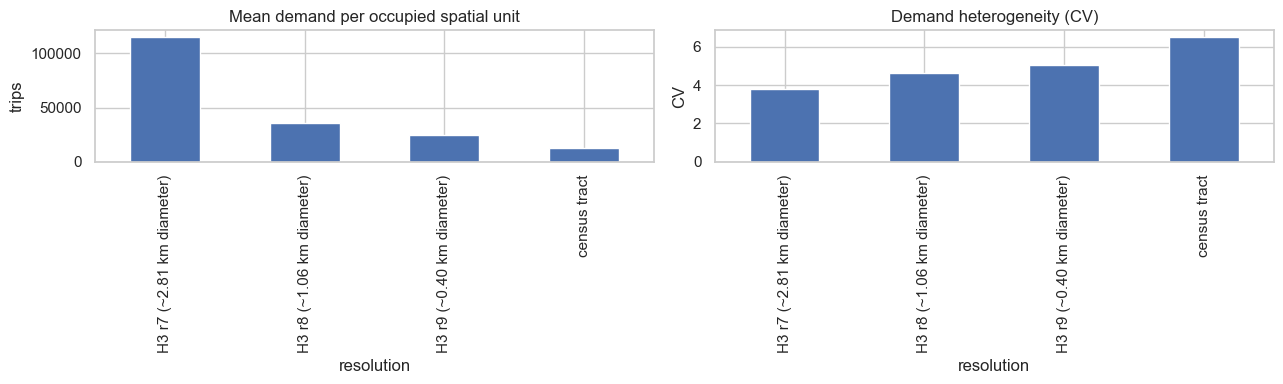

In [8]:
def resolution_metrics(frame, key, label):
    grouped = frame.groupby(key, dropna=True).agg(
        trips=("trips", "sum"),
        weighted_miles=("mean_miles", lambda x: np.nan),
    ).reset_index()
    counts = grouped.trips.sort_values(ascending=False)
    return {
        "resolution": label, "units_with_demand": len(counts),
        "mean_trips_per_unit": counts.mean(), "median_trips_per_unit": counts.median(),
        "cv_demand": counts.std() / counts.mean(),
        "top_10_unit_share": counts.head(10).sum() / counts.sum(),
    }

resolution_rows = []
for res in (7, 8, 9):
    edge = h3.average_hexagon_edge_length(res, unit="km")
    resolution_rows.append(resolution_metrics(locations, f"h3_{res}", f"H3 r{res} (~{2*edge:.2f} km diameter)"))
resolution_rows.append(resolution_metrics(locations, "census_tract", "census tract"))
resolution_summary = pd.DataFrame(resolution_rows).set_index("resolution")
display(resolution_summary.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
resolution_summary.mean_trips_per_unit.plot.bar(ax=axes[0], title="Mean demand per occupied spatial unit")
resolution_summary.cv_demand.plot.bar(ax=axes[1], title="Demand heterogeneity (CV)")
axes[0].set_ylabel("trips"); axes[1].set_ylabel("CV")
plt.tight_layout(); plt.show()

### Pickup versus dropoff concentration across H3 resolutions

Trips without released dropoff coordinates stay in every analysis that does not need a destination. We exclude them only from destination aggregations, because assigning them an H3 cell would invent a location.

In [9]:
end_resolution_rows = []
for role, frame in [("pickup", locations), ("drop-off", destinations)]:
    for res in (7, 8, 9):
        counts = frame.groupby(f"h3_{res}", dropna=True).trips.sum().sort_values(ascending=False)
        end_resolution_rows.append({
            "role": role, "h3_resolution": res, "mapped_trips": counts.sum(),
            "occupied_cells": len(counts), "median_trips_per_cell": counts.median(),
            "top_10_cell_share": counts.head(10).sum() / counts.sum(),
            "demand_cv": counts.std() / counts.mean(),
        })
origin_destination_resolution = pd.DataFrame(end_resolution_rows).set_index(["role", "h3_resolution"])
display(origin_destination_resolution.round(3))

mapped_trips  occupied_cells  median_trips_per_cell  \
role     h3_resolution                                                        
pickup   7                  13387586             116                11453.0   
         8                  13387586             376                   32.5   
         9                  13387586             532                   23.5   
drop-off 7                  12447158             121                13175.0   
         8                  12447158             452                   43.0   
         9                  12447158             658                   39.5   

                        top_10_cell_share  demand_cv  
role     h3_resolution                                
pickup   7                          0.817      3.791  
         8                          0.679      4.629  
         9                          0.602      5.027  
drop-off 7                          0.742      3.947  
         8                          0.553      4.319  
         9                          0.461      4.435

### Joint spatial and temporal resolution sensitivity

We look at this from two angles. The first only considers bins where at least one pickup happened. That tells us how intense active places are, but it hides sparsity. The second treats every combination of spatial unit and time bin in the study area as an observation, including the zero demand ones. This complete grid view is needed for a fair comparison, because finer grids create many more opportunities for zeros.

The occupied bin table uses all trips with a published pickup location. For the complete grid comparison we additionally restrict every spatial system to the same trips, namely those whose census tract identifier matches the available census geometry. Otherwise census tracts and H3 would be evaluated on different samples.

In [10]:
location_resolution_map = locations[["location_id", "h3_7", "h3_8", "h3_9"]].drop_duplicates()
con.register("location_resolution_map", location_resolution_map)
spatial_units = {
    "H3 r7": "m.h3_7", "H3 r8": "m.h3_8", "H3 r9": "m.h3_9",
    "census tract": "CAST(t.pickup_census_tract AS VARCHAR)",
}

occupied_rows = []
for time_label, interval in {
    "15 min": "15 minutes", "1 hour": "1 hour",
    "2 hours": "2 hours", "4 hours": "4 hours",
}.items():
    for spatial_label, unit_expr in spatial_units.items():
        result = con.execute(f"""
            WITH counts AS (
                SELECT TIME_BUCKET(INTERVAL '{interval}', t.trip_start_timestamp) AS time_bin,
                       {unit_expr} AS spatial_unit, COUNT(*) AS trips
                FROM trips t
                LEFT JOIN location_resolution_map m
                    ON t.pickup_centroid_location = m.location_id
                WHERE {unit_expr} IS NOT NULL
                GROUP BY 1, 2
            )
            SELECT COUNT(DISTINCT spatial_unit), COUNT(*), AVG(trips), MEDIAN(trips),
                   STDDEV_SAMP(trips) / AVG(trips), QUANTILE_CONT(trips, .95)
            FROM counts
        """).fetchone()
        occupied_rows.append((spatial_label, time_label, *result))

occupied_bin_summary = pd.DataFrame(occupied_rows, columns=[
    "spatial_resolution", "temporal_resolution", "units_with_demand",
    "occupied_unit_bins", "mean_trips_positive", "median_trips_positive",
    "cv_positive", "p95_trips_positive",
]).set_index(["spatial_resolution", "temporal_resolution"])
display(occupied_bin_summary.round(2))

,,units_with_demand,occupied_unit_bins,mean_trips_positive,median_trips_positive,cv_positive,p95_trips_positive
spatial_resolution,temporal_resolution,,,,,,
H3 r7,15 min,116,2072392,6.46,2.0,2.17,33.0
H3 r8,15 min,376,2619084,5.11,2.0,1.58,22.0
H3 r9,15 min,532,2878160,4.65,2.0,1.47,19.0
census tract,15 min,468,968427,6.25,4.0,1.23,22.0
H3 r7,1 hour,116,905044,14.79,3.0,2.94,69.0
H3 r8,1 hour,376,1144651,11.70,3.0,2.18,61.0
H3 r9,1 hour,532,1251512,10.70,3.0,2.03,49.0
census tract,1 hour,468,387698,15.61,6.0,1.65,64.0
H3 r7,2 hours,116,553964,24.17,4.0,3.25,103.0


### Complete grid sparsity and a fair comparison

The Gold pipeline provides complete spatial grids for census tracts and for H3 resolutions 7, 8 and 9. We use those files only to define the valid spatial units and the common study period, and then aggregate demand again from trip level data after restricting all four spatial systems to the same census matched trips.

This separation matters because a census code being present does not mean it exists in the supplied census geometry (see the coverage audit below). The complete grid statistics are computed analytically from the occupied counts, so we never have to materialize hundreds of millions of zero rows.

,all_trips,h3_mapped_trips,census_code_present,census_grid_matched,common_sample_pct
0,13387586,13387586,6050103,2830710,21.14


,,grid_units,time_bins,total_unit_bins,occupied_unit_bins,zero_bin_share,total_common_trips,mean_trips_all_bins,cv_all_bins,median_trips_positive,p95_trips_positive
spatial_resolution,temporal_resolution,,,,,,,,,,
H3 r7,15 min,152,81697,12417944,220470,0.982,2830710,0.228,11.397,6.0,44.0
H3 r8,15 min,853,81697,69687541,441082,0.994,2830710,0.041,18.979,4.0,19.0
H3 r9,15 min,5971,81697,487812787,503410,0.999,2830710,0.006,44.335,4.0,17.0
census tract,15 min,878,81697,71729966,521939,0.993,2830710,0.039,16.768,4.0,17.0
H3 r7,1 hour,152,20425,3104600,83521,0.973,2830710,0.912,11.139,8.0,150.0
H3 r8,1 hour,853,20425,17422525,168463,0.990,2830710,0.162,18.207,8.0,62.0
H3 r9,1 hour,5971,20425,121957675,197463,0.998,2830710,0.023,42.118,7.0,55.0
census tract,1 hour,878,20425,17933150,207931,0.988,2830710,0.158,15.908,7.0,52.0
H3 r7,2 hours,152,10213,1552376,52283,0.966,2830710,1.823,10.972,8.0,269.0


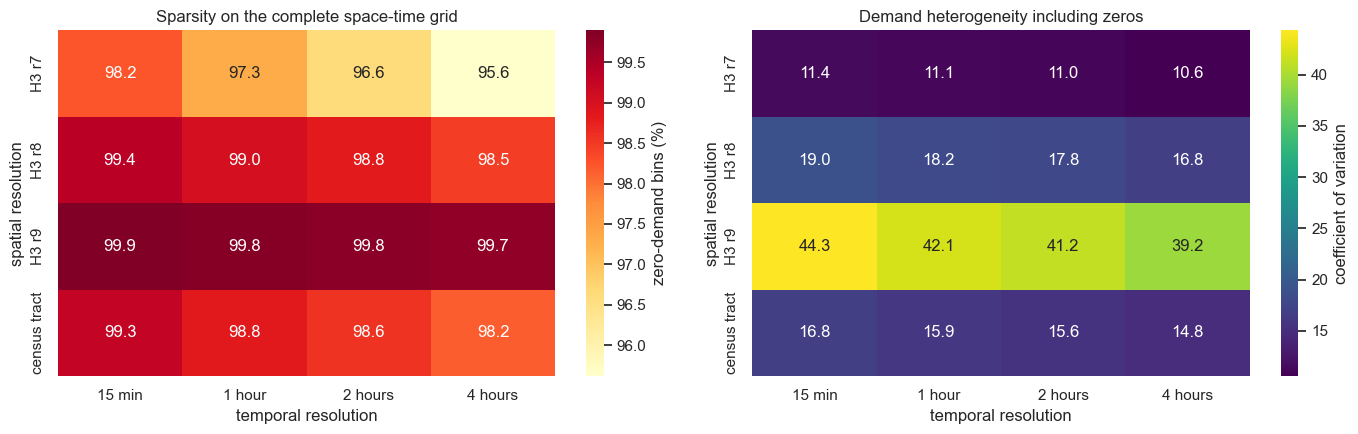

In [11]:
processed_dir = Path(GOLD).parent
comparison_grid_files = {
    "H3 r7": (processed_dir / "GOLD_1H_DEMAND_HEXAGON_R7.parquet", "h3_cell"),
    "H3 r8": (PATHS.gold_1h_demand_hexagon, "h3_cell"),
    "H3 r9": (processed_dir / "GOLD_1H_DEMAND_HEXAGON_R9.parquet", "h3_cell"),
    "census tract": (PATHS.gold_1h_demand_census_tracts, "census_tract"),
}
missing_grids = [str(path) for path, _ in comparison_grid_files.values() if not Path(path).exists()]
if missing_grids:
    raise FileNotFoundError(
        "Generate the complete Gold resolution-comparison datasets first: "
        + ", ".join(missing_grids)
    )

census_grid_path = Path(PATHS.gold_1h_demand_census_tracts).as_posix().replace("'", "''")
con.execute(f"""
    CREATE OR REPLACE TEMP VIEW valid_census_ids AS
    SELECT DISTINCT census_tract
    FROM read_parquet('{census_grid_path}')
""")

spatial_coverage = con.sql("""
    SELECT
        COUNT(*) AS all_trips,
        COUNT(*) FILTER (WHERE t.pickup_h3_cell IS NOT NULL) AS h3_mapped_trips,
        COUNT(*) FILTER (WHERE t.pickup_census_tract IS NOT NULL) AS census_code_present,
        COUNT(*) FILTER (WHERE c.census_tract IS NOT NULL) AS census_grid_matched,
        ROUND(100.0 * COUNT(*) FILTER (WHERE c.census_tract IS NOT NULL) / COUNT(*), 2)
            AS common_sample_pct
    FROM trips t
    LEFT JOIN valid_census_ids c
        ON t.pickup_census_tract = c.census_tract
""").df()
display(spatial_coverage)

# Materialize only the common trip sample and its occupied 15-minute bins.
# Coarser temporal resolutions can then be derived without rescanning all trips.
con.execute("""
    CREATE OR REPLACE TEMP TABLE common_trip_locations AS
    SELECT t.trip_start_timestamp,
           CAST(t.pickup_census_tract AS VARCHAR) AS census_tract,
           m.h3_7, m.h3_8, m.h3_9
    FROM trips t
    JOIN location_resolution_map m
        ON t.pickup_centroid_location = m.location_id
    JOIN valid_census_ids c
        ON t.pickup_census_tract = c.census_tract
""")

common_count_parts = []
for spatial_label, spatial_col in {
    "H3 r7": "h3_7", "H3 r8": "h3_8", "H3 r9": "h3_9",
    "census tract": "census_tract",
}.items():
    common_count_parts.append(f"""
        SELECT '{spatial_label}' AS spatial_resolution,
               {spatial_col} AS spatial_unit,
               TIME_BUCKET(INTERVAL '15 minutes', trip_start_timestamp) AS time_15m,
               COUNT(*)::BIGINT AS trips
        FROM common_trip_locations
        WHERE {spatial_col} IS NOT NULL
        GROUP BY 1, 2, 3
    """)
con.execute(
    "CREATE OR REPLACE TEMP TABLE common_15m_counts AS "
    + " UNION ALL ".join(common_count_parts)
)

grid_units = {}
for spatial_label, (grid_path, spatial_col) in comparison_grid_files.items():
    grid_units[spatial_label] = con.execute(
        f"SELECT COUNT(DISTINCT {spatial_col}) FROM read_parquet(?)",
        [str(grid_path)],
    ).fetchone()[0]

study_start, study_end = con.execute(
    "SELECT MIN(datetime_hour), MAX(datetime_hour) FROM read_parquet(?)",
    [str(PATHS.gold_1h_demand_hexagon)],
).fetchone()

complete_rows = []
for time_label, interval, minutes in [
    ("15 min", "15 minutes", 15),
    ("1 hour", "1 hour", 60),
    ("2 hours", "2 hours", 120),
    ("4 hours", "4 hours", 240),
]:
    n_time_bins = int((study_end - study_start).total_seconds() // (minutes * 60)) + 1
    rebinned = con.execute(f"""
        WITH counts AS (
            SELECT spatial_resolution, spatial_unit,
                   TIME_BUCKET(INTERVAL '{interval}', time_15m) AS time_bin,
                   SUM(trips)::DOUBLE AS trips
            FROM common_15m_counts
            GROUP BY 1, 2, 3
        )
        SELECT spatial_resolution,
               COUNT(*) AS occupied_bins,
               SUM(trips) AS total_trips,
               SUM(trips * trips) AS sum_squares,
               MEDIAN(trips) AS median_positive,
               QUANTILE_CONT(trips, .95) AS p95_positive
        FROM counts
        GROUP BY 1
        ORDER BY 1
    """).fetchall()

    for spatial_label, occupied, total, sum_squares, median_positive, p95_positive in rebinned:
        total_bins = grid_units[spatial_label] * n_time_bins
        mean_all = total / total_bins
        variance_all = max(
            (sum_squares - total * total / total_bins) / (total_bins - 1),
            0.0,
        )
        complete_rows.append({
            "spatial_resolution": spatial_label,
            "temporal_resolution": time_label,
            "grid_units": grid_units[spatial_label],
            "time_bins": n_time_bins,
            "total_unit_bins": total_bins,
            "occupied_unit_bins": occupied,
            "zero_bin_share": 1 - occupied / total_bins,
            "total_common_trips": int(total),
            "mean_trips_all_bins": mean_all,
            "cv_all_bins": np.sqrt(variance_all) / mean_all,
            "median_trips_positive": median_positive,
            "p95_trips_positive": p95_positive,
        })

complete_grid_summary = pd.DataFrame(complete_rows).set_index([
    "spatial_resolution", "temporal_resolution"
])
display(complete_grid_summary.round(3))

spatial_order = ["H3 r7", "H3 r8", "H3 r9", "census tract"]
temporal_order = ["15 min", "1 hour", "2 hours", "4 hours"]
zero_share_matrix = (
    100 * complete_grid_summary.zero_bin_share.unstack("temporal_resolution")
).reindex(index=spatial_order, columns=temporal_order)
cv_all_matrix = complete_grid_summary.cv_all_bins.unstack(
    "temporal_resolution"
).reindex(index=spatial_order, columns=temporal_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.heatmap(
    zero_share_matrix,
    annot=True, fmt=".1f", cmap="YlOrRd", ax=axes[0],
    cbar_kws={"label": "zero-demand bins (%)"},
)
axes[0].set(title="Sparsity on the complete space-time grid", xlabel="temporal resolution", ylabel="spatial resolution")
sns.heatmap(
    cv_all_matrix,
    annot=True, fmt=".1f", cmap="viridis", ax=axes[1],
    cbar_kws={"label": "coefficient of variation"},
)
axes[1].set(title="Demand heterogeneity including zeros", xlabel="temporal resolution", ylabel="spatial resolution")
plt.tight_layout()
plt.show()

#### How to read the table

`zero_bin_share` is the share of valid unit and time combinations without a single pickup. It is our main sparsity measure and has to grow as the grid gets finer. `mean_trips_all_bins` and `cv_all_bins` include the zeros, so they describe the problem a fleet operator or a prediction model actually faces. `median_trips_positive` and `p95_trips_positive` only describe active bins and answer a different question: how busy is a place once it is active at all?

`total_common_trips` being identical across the spatial systems is a built in sanity check; if it differed we would have a mapping loss or a bug. And once more, very fine H3 cells do not mean equally fine positional accuracy, since many locations are published as area centroids.

### Trip characteristics across H3 and temporal resolutions

The demand table above asks how many pickups occur in a spatial-time bin. We now apply
the same aggregation logic to trip distance, duration and fare. One observation in the
following analysis is an **occupied H3 cell × time-bin combination**.

For every combination we first calculate its trip count and its median trip
characteristics. We then summarize those bin-level medians across all occupied bins.
This is intentionally not weighted by trip count: it describes a typical active
cell-time bin rather than reproducing the citywide trip median. The share of bins with
fewer than five trips makes the loss of stability at fine resolutions explicit.

,,occupied_bins,represented_trips,median_trips_per_bin,bins_below_five_pct,typical_bin_median_miles,p25_bin_median_miles,p75_bin_median_miles,typical_bin_median_minutes,p25_bin_median_minutes,p75_bin_median_minutes,typical_bin_median_fare,p25_bin_median_fare,p75_bin_median_fare
spatial_resolution,temporal_resolution,,,,,,,,,,,,,
H3 r7,15 min,2072392,13387586,2.0,75.23,7.97,3.24,11.68,20.00,13.40,28.00,24.75,13.32,31.50
H3 r8,15 min,2619084,13387586,2.0,73.37,6.26,2.16,11.19,17.93,11.30,26.28,20.66,10.44,30.50
H3 r9,15 min,2878160,13387586,2.0,73.48,5.40,1.83,10.90,17.00,10.58,25.52,18.75,9.70,30.00
H3 r7,1 hour,905044,13387586,3.0,64.90,8.82,4.31,11.61,20.58,14.80,27.55,26.50,16.12,31.25
H3 r8,1 hour,1144651,13387586,3.0,62.90,7.48,2.87,11.24,19.00,12.68,26.28,23.62,12.25,30.50
H3 r9,1 hour,1251512,13387586,3.0,61.02,6.70,2.30,11.02,18.00,11.65,25.60,21.75,10.77,30.25
H3 r7,4 hours,323074,13387586,6.0,43.33,9.31,5.32,11.46,21.00,15.97,27.00,27.50,18.56,30.75
H3 r8,4 hours,424292,13387586,6.0,44.28,8.03,3.40,11.10,19.52,13.72,25.88,25.00,13.77,30.25
H3 r9,4 hours,466697,13387586,6.0,43.47,7.31,2.72,10.90,18.70,12.39,25.18,23.38,11.88,30.00


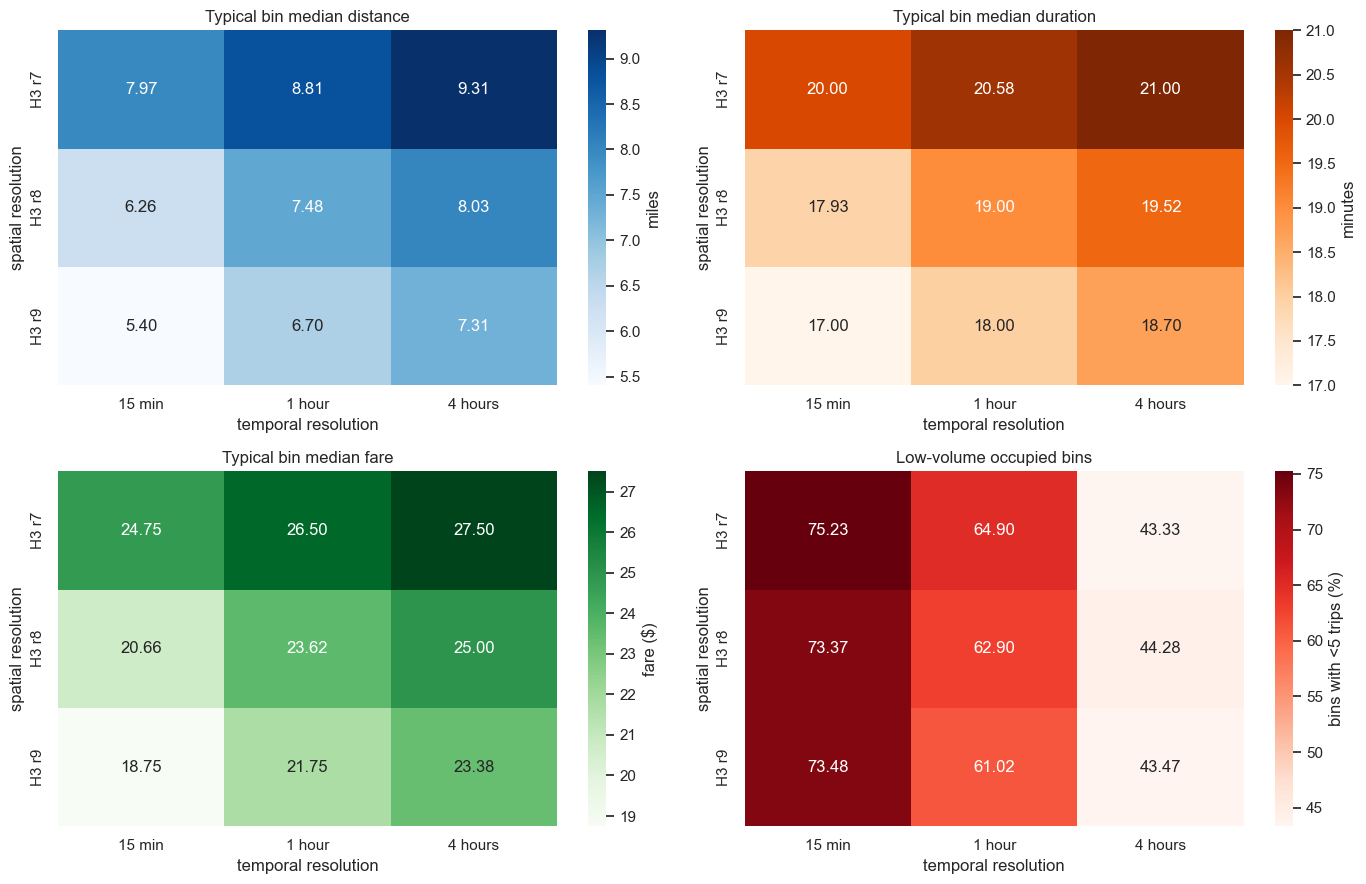

In [12]:
h3_resolution_specs = {
    "H3 r7": "m.h3_7",
    "H3 r8": "m.h3_8",
    "H3 r9": "m.h3_9",
}
characteristic_rows = []
for time_label, interval in {
    "15 min": "15 minutes",
    "1 hour": "1 hour",
    "4 hours": "4 hours",
}.items():
    for spatial_label, unit_expr in h3_resolution_specs.items():
        result = con.execute(f"""
            WITH bin_metrics AS (
                SELECT
                    TIME_BUCKET(
                        INTERVAL '{interval}', t.trip_start_timestamp
                    ) AS time_bin,
                    {unit_expr} AS spatial_unit,
                    COUNT(*) AS trips,
                    MEDIAN(t.trip_miles) AS median_miles,
                    MEDIAN(t.trip_seconds) / 60 AS median_minutes,
                    MEDIAN(t.fare) AS median_fare
                FROM trips t
                JOIN location_resolution_map m
                  ON t.pickup_centroid_location = m.location_id
                WHERE {unit_expr} IS NOT NULL
                GROUP BY 1, 2
            )
            SELECT
                COUNT(*) AS occupied_bins,
                SUM(trips) AS represented_trips,
                MEDIAN(trips) AS median_trips_per_bin,
                100.0 * AVG(CASE WHEN trips < 5 THEN 1 ELSE 0 END)
                    AS bins_below_five_pct,
                MEDIAN(median_miles) AS typical_bin_median_miles,
                QUANTILE_CONT(median_miles, .25) AS p25_bin_median_miles,
                QUANTILE_CONT(median_miles, .75) AS p75_bin_median_miles,
                MEDIAN(median_minutes) AS typical_bin_median_minutes,
                QUANTILE_CONT(median_minutes, .25) AS p25_bin_median_minutes,
                QUANTILE_CONT(median_minutes, .75) AS p75_bin_median_minutes,
                MEDIAN(median_fare) AS typical_bin_median_fare,
                QUANTILE_CONT(median_fare, .25) AS p25_bin_median_fare,
                QUANTILE_CONT(median_fare, .75) AS p75_bin_median_fare
            FROM bin_metrics
        """).fetchone()
        characteristic_rows.append((spatial_label, time_label, *result))

spatiotemporal_characteristics = pd.DataFrame(
    characteristic_rows,
    columns=[
        "spatial_resolution", "temporal_resolution",
        "occupied_bins", "represented_trips", "median_trips_per_bin",
        "bins_below_five_pct",
        "typical_bin_median_miles", "p25_bin_median_miles",
        "p75_bin_median_miles",
        "typical_bin_median_minutes", "p25_bin_median_minutes",
        "p75_bin_median_minutes",
        "typical_bin_median_fare", "p25_bin_median_fare",
        "p75_bin_median_fare",
    ],
).set_index(["spatial_resolution", "temporal_resolution"])
display(spatiotemporal_characteristics.round(2))

spatial_order_h3 = ["H3 r7", "H3 r8", "H3 r9"]
temporal_order_h3 = ["15 min", "1 hour", "4 hours"]
heatmap_specs = [
    ("typical_bin_median_miles", "Typical bin median distance", "miles", "Blues"),
    ("typical_bin_median_minutes", "Typical bin median duration", "minutes", "Oranges"),
    ("typical_bin_median_fare", "Typical bin median fare", "fare ($)", "Greens"),
    ("bins_below_five_pct", "Low-volume occupied bins", "bins with <5 trips (%)", "Reds"),
]
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, (column, title, colorbar_label, cmap) in zip(axes.flat, heatmap_specs):
    matrix = (
        spatiotemporal_characteristics[column]
        .unstack("temporal_resolution")
        .reindex(index=spatial_order_h3, columns=temporal_order_h3)
    )
    sns.heatmap(
        matrix, annot=True, fmt=".2f", cmap=cmap, ax=ax,
        cbar_kws={"label": colorbar_label},
    )
    ax.set(title=title, xlabel="temporal resolution", ylabel="spatial resolution")
plt.tight_layout()
plt.show()

#### Reading the characteristic-resolution comparison

Changes across rows and columns do not mean that the underlying trips changed. They
show how the **analytical observation** changes when trips are packaged into different
cell-time bins. Fine H3 and 15-minute bins create many small samples; their medians can
therefore jump because a single airport or long-distance trip has much more influence.
Coarser bins pool more heterogeneous trips but give more stable summaries.

The table should always be read together with `median_trips_per_bin` and
`bins_below_five_pct`. A configuration with a high low-volume share is informative for
local peaks, but risky as a direct target for prediction without pooling, regularization
or a count model designed for sparse data.

In the observed results, all nine configurations represent the same 13,387,586 trips, which is the key coverage check. At 15-minute resolution, 73-75% of occupied H3 bins contain fewer than five trips; even at four hours the share remains about 43-44%. The typical bin-level median therefore depends strongly on the chosen partition. For example, at 15 minutes it falls from 7.97 miles, 20.00 minutes and $24.75 in H3 r7 to 5.40 miles, 17.00 minutes and $18.75 in H3 r9. This is an aggregation effect: finer cells separate compact central trips from airport and cross-city activity, while coarse cells mix them more often.

### Dominant flows between areas

,origin_name,destination_name,trips,median_miles,median_minutes,median_fare
0,Near North Side,Near North Side,923486,0.88,6.53,6.75
1,Loop,Near North Side,684869,1.30,8.90,8.25
2,Near North Side,Loop,651549,1.31,9.00,8.50
3,Ohare,Near North Side,592916,17.40,41.58,44.25
4,Loop,Loop,447820,0.80,6.00,6.25
5,Near West Side,Near North Side,421868,1.75,11.48,9.21
6,Near North Side,Near West Side,398223,1.80,12.00,9.53
7,Ohare,Loop,378722,17.82,42.63,45.25
8,Near West Side,Loop,366594,1.02,7.28,6.75
9,Loop,Near West Side,352919,1.17,8.00,7.50


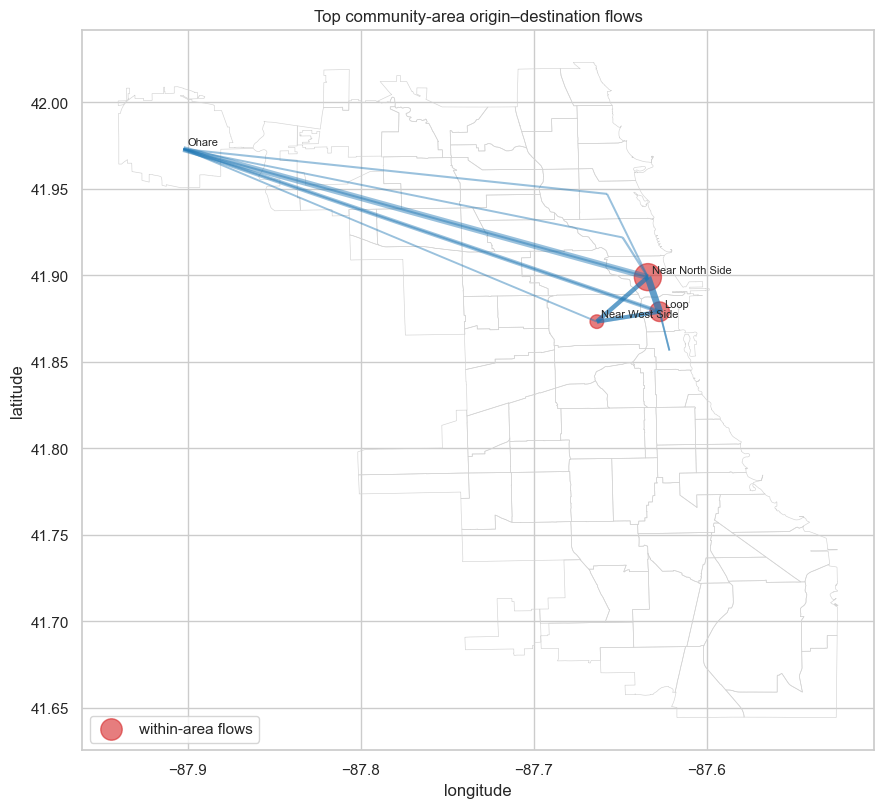

In [13]:
top_flows = con.sql("""
SELECT
    pickup_community_area::INTEGER AS origin_area,
    dropoff_community_area::INTEGER AS destination_area,
    COUNT(*) AS trips,
    ROUND(MEDIAN(trip_miles), 2) AS median_miles,
    ROUND(MEDIAN(trip_seconds) / 60, 2) AS median_minutes,
    ROUND(MEDIAN(fare), 2) AS median_fare
FROM trips
WHERE pickup_community_area IS NOT NULL
  AND dropoff_community_area IS NOT NULL
GROUP BY 1, 2
ORDER BY trips DESC
LIMIT 20
""").df()

origin_names = community_names.rename(columns={
    "area": "origin_area", "community_name": "origin_name"
})
destination_names = community_names.rename(columns={
    "area": "destination_area", "community_name": "destination_name"
})
top_flows = (
    top_flows.merge(origin_names, on="origin_area", how="left")
    .merge(destination_names, on="destination_area", how="left")
)
display(top_flows[[
    "origin_name", "destination_name", "trips",
    "median_miles", "median_minutes", "median_fare",
]])

# Compute representative community-area points in a projected CRS before returning to WGS84.
community_centers = community_areas.to_crs("EPSG:26916")[["area", "geometry"]].copy()
community_centers["geometry"] = community_centers.geometry.representative_point()
community_centers = community_centers.to_crs("EPSG:4326")
center_lookup = dict(
    zip(community_centers["area"].astype(int), community_centers.geometry)
)

cross_flows = top_flows[top_flows.origin_area != top_flows.destination_area].copy()
cross_flows = gpd.GeoDataFrame(
    cross_flows,
    geometry=[
        LineString([center_lookup[int(origin)], center_lookup[int(destination)]])
        for origin, destination in zip(cross_flows.origin_area, cross_flows.destination_area)
    ],
    crs="EPSG:4326",
)
self_flows = top_flows[top_flows.origin_area == top_flows.destination_area].copy()
self_flows = gpd.GeoDataFrame(
    self_flows,
    geometry=[center_lookup[int(area)] for area in self_flows.origin_area],
    crs="EPSG:4326",
)

fig, ax = plt.subplots(figsize=(9, 9))
community_areas.boundary.plot(ax=ax, color="lightgray", linewidth=.45)
max_flow = top_flows.trips.max()
for _, flow in cross_flows.sort_values("trips").iterrows():
    gpd.GeoSeries([flow.geometry], crs="EPSG:4326").plot(
        ax=ax, color="tab:blue", alpha=.45,
        linewidth=.5 + 6 * flow.trips / max_flow,
    )
if not self_flows.empty:
    self_flows.plot(
        ax=ax, color="tab:red", alpha=.6,
        markersize=30 + 350 * self_flows.trips / max_flow,
        label="within-area flows",
    )
for area in [8, 32, 76, 28]:
    point = center_lookup[area]
    name = community_names.loc[community_names.area == area, "community_name"].iloc[0]
    ax.annotate(name, (point.x, point.y), fontsize=8, xytext=(3, 3), textcoords="offset points")
ax.set(
    title="Top community-area origin–destination flows",
    xlabel="longitude", ylabel="latitude", aspect="equal",
)
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

### Reading the flow map

The largest single flow stays within Near North Side, followed by the connections between the Loop, Near North Side and Near West Side. Flows from O'Hare into the center are fewer in number but much longer and more expensive, which explains part of the high distance and fare profile at night and in the early morning.

Flows that start and end in the same area are drawn as red points, since a line from a point to itself has no meaning. Line thickness encodes trip count only, not revenue or distance, and the straight lines between representative points are of course not actual routes.

### Time-of-day effect within comparable OD and distance groups

The raw hourly curve mixes together very different journeys. For example, an airport
trip and a one-mile downtown trip should not be compared as if only their start time
differed.

To reduce this composition problem, the following comparison keeps only trips between
0.5 and 5 miles and groups them by pickup Community Area, drop-off Community Area and
0.5-mile distance band. Within each group, its median duration in a four-hour period is
compared with that group's median across the full day. We retain only well-observed
groups with at least 500 trips overall and 50 trips in the period.

,period,short_trips,median_miles,median_minutes,median_speed_mph
0,00:00-03:59,159599,2.00,8.78,13.47
1,04:00-07:59,426635,1.57,8.13,11.78
2,08:00-11:59,1713546,1.50,9.15,10.11
3,12:00-15:59,1803156,1.60,9.95,9.81
4,16:00-19:59,1967354,1.62,11.12,8.92
5,20:00-23:59,760536,1.73,9.42,11.15


,period,comparable_od_distance_groups,represented_trips,median_group_duration_deviation_pct,trip_weighted_duration_deviation_pct,median_group_speed_mph
0,00:00-03:59,344,125957.0,-19.80,-18.51,14.53
1,04:00-07:59,420,394755.0,-16.29,-16.27,14.17
2,08:00-11:59,678,1582731.0,-4.31,-3.30,12.56
3,12:00-15:59,683,1637335.0,3.00,1.26,11.45
4,16:00-19:59,679,1822268.0,11.39,12.56,10.76
5,20:00-23:59,586,677625.0,-9.61,-8.15,13.08


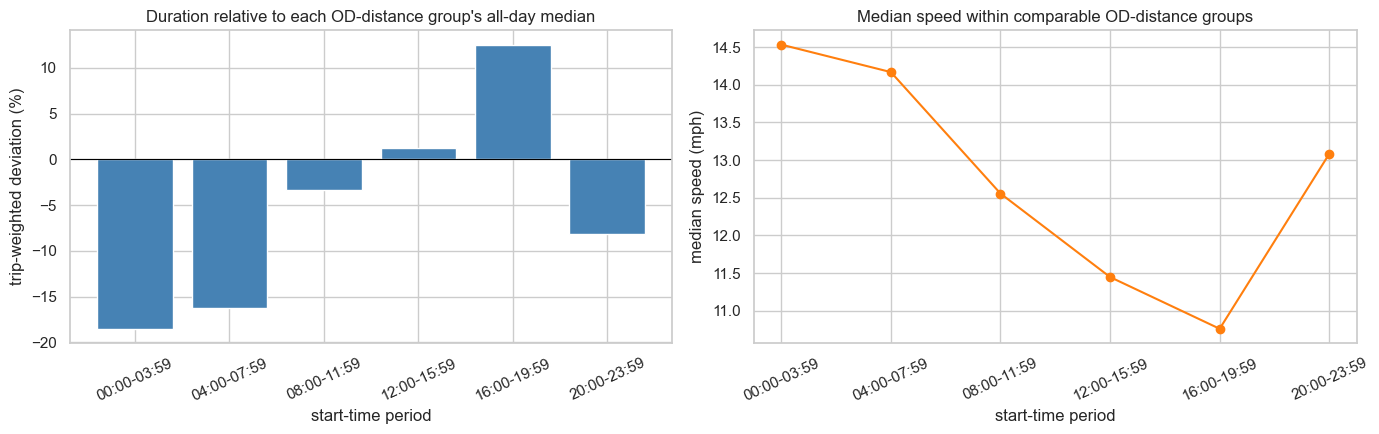

In [14]:
od_controlled_period = con.sql("""
WITH base AS (
    SELECT
        pickup_community_area::INTEGER AS origin_area,
        dropoff_community_area::INTEGER AS destination_area,
        FLOOR(trip_miles * 2) / 2 AS distance_band_start,
        FLOOR(EXTRACT(hour FROM trip_start_timestamp) / 4)::INTEGER * 4
            AS period_start_hour,
        trip_miles,
        trip_seconds / 60 AS minutes,
        3600 * trip_miles / trip_seconds AS speed_mph
    FROM trips
    WHERE pickup_community_area IS NOT NULL
      AND dropoff_community_area IS NOT NULL
      AND trip_miles BETWEEN 0.5 AND 5
      AND trip_seconds BETWEEN 60 AND 7200
), baselines AS (
    SELECT origin_area, destination_area, distance_band_start,
           COUNT(*) AS all_day_trips,
           MEDIAN(minutes) AS all_day_median_minutes
    FROM base
    GROUP BY 1, 2, 3
    HAVING COUNT(*) >= 500
), period_stats AS (
    SELECT origin_area, destination_area, distance_band_start, period_start_hour,
           COUNT(*) AS trips,
           MEDIAN(minutes) AS period_median_minutes,
           MEDIAN(speed_mph) AS period_median_speed_mph
    FROM base
    GROUP BY 1, 2, 3, 4
    HAVING COUNT(*) >= 50
), matched AS (
    SELECT p.*,
           b.all_day_median_minutes,
           100 * (p.period_median_minutes / b.all_day_median_minutes - 1)
               AS duration_deviation_pct
    FROM period_stats p
    JOIN baselines b USING (
        origin_area, destination_area, distance_band_start
    )
)
SELECT
    period_start_hour,
    COUNT(*) AS comparable_od_distance_groups,
    SUM(trips) AS represented_trips,
    MEDIAN(duration_deviation_pct) AS median_group_duration_deviation_pct,
    SUM(trips * duration_deviation_pct) / SUM(trips)
        AS trip_weighted_duration_deviation_pct,
    MEDIAN(period_median_speed_mph) AS median_group_speed_mph
FROM matched
GROUP BY 1
ORDER BY 1
""").df()
od_controlled_period["period"] = od_controlled_period.period_start_hour.map(
    lambda hour: f"{hour:02d}:00-{hour + 3:02d}:59"
)

raw_short_trip_period = con.sql("""
SELECT
    FLOOR(EXTRACT(hour FROM trip_start_timestamp) / 4)::INTEGER * 4
        AS period_start_hour,
    COUNT(*) AS short_trips,
    MEDIAN(trip_miles) AS median_miles,
    MEDIAN(trip_seconds) / 60 AS median_minutes,
    MEDIAN(3600 * trip_miles / trip_seconds) AS median_speed_mph
FROM trips
WHERE trip_miles BETWEEN 0.5 AND 5
  AND trip_seconds BETWEEN 60 AND 7200
GROUP BY 1
ORDER BY 1
""").df()
raw_short_trip_period["period"] = raw_short_trip_period.period_start_hour.map(
    lambda hour: f"{hour:02d}:00-{hour + 3:02d}:59"
)

display(raw_short_trip_period[[
    "period", "short_trips", "median_miles", "median_minutes", "median_speed_mph",
]].round(2))
display(od_controlled_period[[
    "period", "comparable_od_distance_groups", "represented_trips",
    "median_group_duration_deviation_pct",
    "trip_weighted_duration_deviation_pct", "median_group_speed_mph",
]].round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].bar(
    od_controlled_period.period,
    od_controlled_period.trip_weighted_duration_deviation_pct,
    color="steelblue",
)
axes[0].axhline(0, color="black", linewidth=.8)
axes[0].set(
    title="Duration relative to each OD-distance group's all-day median",
    xlabel="start-time period", ylabel="trip-weighted deviation (%)",
)
axes[1].plot(
    od_controlled_period.period,
    od_controlled_period.median_group_speed_mph,
    marker="o", color="tab:orange",
)
axes[1].set(
    title="Median speed within comparable OD-distance groups",
    xlabel="start-time period", ylabel="median speed (mph)",
)
for ax in axes:
    ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

#### What this comparison can and cannot establish

If duration remains higher and speed lower in the afternoon or evening after this
matching, the pattern is not explained solely by a larger share of short downtown
trips. It is stronger descriptive evidence for a time-of-day travel-speed effect.

It is still not a causal traffic estimate. Community Areas and half-mile bands are
coarse controls, routes are unknown, and unobserved differences such as weather,
events, passenger stops or road choice remain. Accordingly, the notebook uses
“consistent with congestion” and not “caused by congestion”.

The observed pattern survives the controls. For short trips starting from 16:00 to 19:59, raw median duration is 11.12 minutes and raw median speed is 8.92 mph. Across 679 well-observed OD-distance groups representing 1,822,268 trips, duration is still 12.56% above the respective groups all-day medians on a trip-weighted basis; median group speed is 10.76 mph. From 00:00 to 03:59, the corresponding duration deviation is -18.51% and median group speed is 14.53 mph. Thus a changing mixture of origins, destinations and broad distance classes does not fully explain the evening slowdown.

## 6. Approximate idle time between trips

For each taxi we compare the previous published end timestamp with the next start. Both are rounded to 15 minutes, so an individual gap easily carries 15 minutes of measurement uncertainty in either direction. Negative gaps are not automatically data errors here, adjacent short trips can overlap after rounding. We keep gaps between 0 and 12 hours and report medians next to means.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,all_trips,trips_with_previous_trip,nonnegative_gaps,retained_gaps_0_to_720_min,retained_share_of_all_trips_pct
0,13387586,13384273,13212318,11760210,87.84


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,hour,usable_gaps,mean_idle_minutes,median_idle_minutes,p90_idle_minutes
0,0,193923,84.26,45.0,195.0
1,1,110242,81.49,45.0,195.0
2,2,62648,83.33,45.0,195.0
3,3,44573,105.48,45.0,270.0
4,4,51002,170.42,60.0,570.0
5,5,85562,242.17,90.0,645.0
6,6,175876,206.49,45.0,660.0
7,7,370693,128.30,15.0,615.0
8,8,587160,82.73,15.0,240.0
9,9,643985,67.38,15.0,135.0


,area,community_name,usable_gaps,median_idle_minutes,p90_idle_minutes
0,8,Near North Side,2829778,15.0,75.0
1,76,Ohare,2278532,105.0,255.0
2,32,Loop,2074489,15.0,75.0
3,28,Near West Side,1285361,15.0,75.0
4,33,Near South Side,431912,15.0,90.0
5,6,Lake View,372931,30.0,285.0
6,56,Garfield Ridge,305505,90.0,225.0
7,7,Lincoln Park,262932,15.0,120.0
8,3,Uptown,176109,30.0,495.0
9,24,West Town,126458,15.0,90.0


,,occupied_bins,represented_gaps,median_gaps_per_bin,bins_below_five_pct,typical_bin_median_idle,p25_bin_median_idle,p75_bin_median_idle
spatial_resolution,temporal_resolution,,,,,,,
H3 r7,15 min,1930756,11760210,2.0,76.61,30.0,15.0,75.0
H3 r8,15 min,2458482,11760210,2.0,74.58,30.0,15.0,60.0
H3 r9,15 min,2713656,11760210,2.0,74.94,30.0,15.0,60.0
H3 r7,1 hour,861765,11760210,2.0,66.78,30.0,15.0,60.0
H3 r8,1 hour,1091525,11760210,3.0,64.45,30.0,15.0,52.5
H3 r9,1 hour,1196662,11760210,3.0,62.55,22.5,15.0,45.0
H3 r7,4 hours,314284,11760210,5.0,46.03,30.0,15.0,45.0
H3 r8,4 hours,411778,11760210,5.0,46.88,22.5,15.0,45.0
H3 r9,4 hours,453321,11760210,5.0,45.93,22.5,15.0,45.0


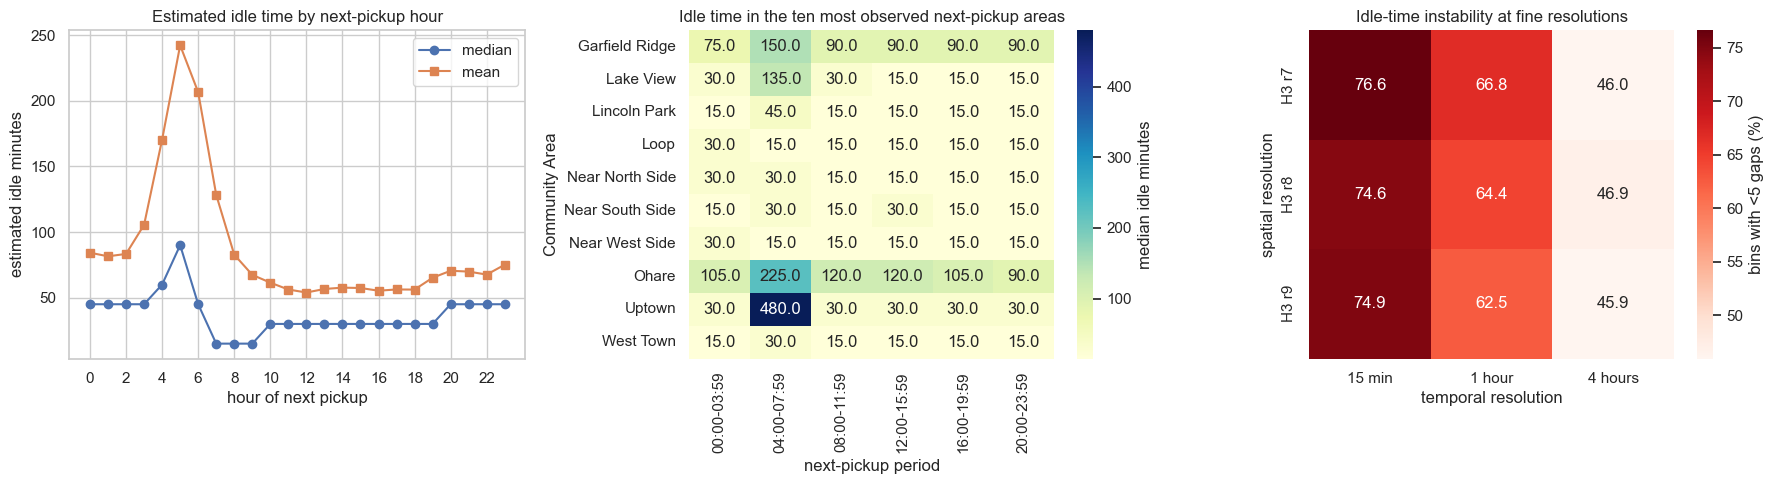

In [15]:
idle_gap_coverage = con.sql("""
WITH ordered AS (
    SELECT
        trip_start_timestamp,
        LAG(trip_end_timestamp) OVER (
            PARTITION BY taxi_id
            ORDER BY trip_start_timestamp, trip_id
        ) AS previous_end
    FROM trips
), gaps AS (
    SELECT *,
           EPOCH(trip_start_timestamp - previous_end) / 60 AS idle_minutes
    FROM ordered
)
SELECT
    COUNT(*) AS all_trips,
    COUNT(previous_end) AS trips_with_previous_trip,
    COUNT(*) FILTER (
        WHERE previous_end IS NOT NULL AND idle_minutes >= 0
    ) AS nonnegative_gaps,
    COUNT(*) FILTER (
        WHERE idle_minutes BETWEEN 0 AND 720
    ) AS retained_gaps_0_to_720_min,
    ROUND(
        100.0 * COUNT(*) FILTER (WHERE idle_minutes BETWEEN 0 AND 720)
        / COUNT(*), 2
    ) AS retained_share_of_all_trips_pct
FROM gaps
""").df()
display(idle_gap_coverage)

con.execute("""
CREATE OR REPLACE TEMP TABLE idle_events AS
WITH ordered AS (
    SELECT
        trip_start_timestamp,
        pickup_centroid_location,
        pickup_community_area,
        LAG(trip_end_timestamp) OVER (
            PARTITION BY taxi_id
            ORDER BY trip_start_timestamp, trip_id
        ) AS previous_end
    FROM trips
)
SELECT
    o.trip_start_timestamp AS next_pickup_timestamp,
    EXTRACT(hour FROM o.trip_start_timestamp)::INTEGER AS next_pickup_hour,
    o.pickup_community_area::INTEGER AS next_pickup_area,
    m.h3_7, m.h3_8, m.h3_9,
    EPOCH(o.trip_start_timestamp - o.previous_end) / 60 AS idle_minutes
FROM ordered o
LEFT JOIN location_resolution_map m
  ON o.pickup_centroid_location = m.location_id
WHERE EPOCH(o.trip_start_timestamp - o.previous_end) / 60
      BETWEEN 0 AND 720
""")

idle_by_hour = con.sql("""
SELECT next_pickup_hour AS hour,
       COUNT(*) AS usable_gaps,
       AVG(idle_minutes) AS mean_idle_minutes,
       MEDIAN(idle_minutes) AS median_idle_minutes,
       QUANTILE_CONT(idle_minutes, .9) AS p90_idle_minutes
FROM idle_events
GROUP BY 1
ORDER BY 1
""").df()
display(idle_by_hour.round(2))

idle_by_area = con.sql("""
SELECT next_pickup_area AS area,
       COUNT(*) AS usable_gaps,
       MEDIAN(idle_minutes) AS median_idle_minutes,
       QUANTILE_CONT(idle_minutes, .9) AS p90_idle_minutes
FROM idle_events
WHERE next_pickup_area IS NOT NULL
GROUP BY 1
ORDER BY usable_gaps DESC
""").df().merge(community_names, on="area", how="left")
display(idle_by_area[[
    "area", "community_name", "usable_gaps",
    "median_idle_minutes", "p90_idle_minutes",
]].head(15).round(2))

top_idle_areas = idle_by_area.head(10).area.tolist()
idle_area_period = con.sql("""
SELECT
    next_pickup_area AS area,
    FLOOR(next_pickup_hour / 4)::INTEGER * 4 AS period_start_hour,
    COUNT(*) AS usable_gaps,
    MEDIAN(idle_minutes) AS median_idle_minutes
FROM idle_events
WHERE next_pickup_area IS NOT NULL
GROUP BY 1, 2
""").df()
idle_area_period = idle_area_period[
    idle_area_period.area.isin(top_idle_areas)
].merge(community_names, on="area", how="left")
idle_area_period["period"] = idle_area_period.period_start_hour.map(
    lambda hour: f"{hour:02d}:00-{hour + 3:02d}:59"
)

idle_resolution_rows = []
for time_label, interval in {
    "15 min": "15 minutes",
    "1 hour": "1 hour",
    "4 hours": "4 hours",
}.items():
    for spatial_label, spatial_column in {
        "H3 r7": "h3_7",
        "H3 r8": "h3_8",
        "H3 r9": "h3_9",
    }.items():
        result = con.execute(f"""
            WITH bin_metrics AS (
                SELECT
                    TIME_BUCKET(
                        INTERVAL '{interval}', next_pickup_timestamp
                    ) AS time_bin,
                    {spatial_column} AS spatial_unit,
                    COUNT(*) AS usable_gaps,
                    MEDIAN(idle_minutes) AS median_idle_minutes
                FROM idle_events
                WHERE {spatial_column} IS NOT NULL
                GROUP BY 1, 2
            )
            SELECT
                COUNT(*) AS occupied_bins,
                SUM(usable_gaps) AS represented_gaps,
                MEDIAN(usable_gaps) AS median_gaps_per_bin,
                100.0 * AVG(CASE WHEN usable_gaps < 5 THEN 1 ELSE 0 END)
                    AS bins_below_five_pct,
                MEDIAN(median_idle_minutes) AS typical_bin_median_idle,
                QUANTILE_CONT(median_idle_minutes, .25)
                    AS p25_bin_median_idle,
                QUANTILE_CONT(median_idle_minutes, .75)
                    AS p75_bin_median_idle
            FROM bin_metrics
        """).fetchone()
        idle_resolution_rows.append((spatial_label, time_label, *result))

idle_resolution_summary = pd.DataFrame(
    idle_resolution_rows,
    columns=[
        "spatial_resolution", "temporal_resolution",
        "occupied_bins", "represented_gaps", "median_gaps_per_bin",
        "bins_below_five_pct", "typical_bin_median_idle",
        "p25_bin_median_idle", "p75_bin_median_idle",
    ],
).set_index(["spatial_resolution", "temporal_resolution"])
display(idle_resolution_summary.round(2))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(
    idle_by_hour.hour, idle_by_hour.median_idle_minutes,
    marker="o", label="median",
)
axes[0].plot(
    idle_by_hour.hour, idle_by_hour.mean_idle_minutes,
    marker="s", label="mean",
)
axes[0].set(
    title="Estimated idle time by next-pickup hour",
    xlabel="hour of next pickup", ylabel="estimated idle minutes",
    xticks=range(0, 24, 2),
)
axes[0].legend()

area_heat = idle_area_period.pivot(
    index="community_name", columns="period", values="median_idle_minutes"
).reindex(columns=[
    "00:00-03:59", "04:00-07:59", "08:00-11:59",
    "12:00-15:59", "16:00-19:59", "20:00-23:59",
])
sns.heatmap(
    area_heat, annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[1],
    cbar_kws={"label": "median idle minutes"},
)
axes[1].set(
    title="Idle time in the ten most observed next-pickup areas",
    xlabel="next-pickup period", ylabel="Community Area",
)

idle_stability_heat = (
    idle_resolution_summary.bins_below_five_pct
    .unstack("temporal_resolution")
    .reindex(index=spatial_order_h3, columns=temporal_order_h3)
)
sns.heatmap(
    idle_stability_heat, annot=True, fmt=".1f", cmap="Reds", ax=axes[2],
    cbar_kws={"label": "bins with <5 gaps (%)"},
)
axes[2].set(
    title="Idle-time instability at fine resolutions",
    xlabel="temporal resolution", ylabel="spatial resolution",
)
plt.tight_layout()
plt.show()

### Reading the idle-time analysis

Idle time is assigned to the **location and time of the next pickup**. It estimates how
long the same published taxi ID had no observed passenger trip before that pickup.
It is not a GPS measurement of where the taxi waited.

The coverage table makes two exclusions visible: the first observed trip of each taxi
has no predecessor, and gaps outside 0-720 minutes are excluded as overlaps, long
breaks, shift changes or likely missing observations. The Community Area heatmap is
therefore operationally descriptive, not a direct measure of cruising or driver
availability.

As with demand, H3 r9 × 15-minute bins contain many very small samples. Differences in
their median idle time should not be interpreted as stable local effects unless the
model pools information across neighbouring cells or longer time periods.

The coverage calculation retains 11,760,210 gaps, or 87.84% of all trips. Many medians are exact multiples of 15 minutes because the published timestamps are rounded, so differences smaller than that are not supported by the data. Central high-demand areas show short observed gaps: Near North Side, the Loop and Near West Side each have a 15-minute overall median. O Hare has 105 minutes and Garfield Ridge 90 minutes. The very high early-morning means and upper quantiles show that a minority of long gaps, breaks or shift transitions strongly stretches the distribution. Finally, 74.6-76.6% of occupied H3 x 15-minute bins have fewer than five usable gaps; at four hours this falls to roughly 46%, which is still sparse.

## 7. Comparison across 2024, 2025, and 2026

Raw annual totals cannot be compared directly because 2026 is only observed until early May. We therefore report coverage and demand per active day, compare the January to April window that all three years share, and measure differences between normalized temporal and spatial demand distributions. The Jensen Shannon distance we use for this is bounded between 0 (identical distributions) and 1 (completely separated).

In [16]:
year_summary = con.sql("""
SELECT
    YEAR(trip_start_timestamp)::INTEGER AS year,
    MIN(CAST(trip_start_timestamp AS DATE)) AS first_date,
    MAX(CAST(trip_start_timestamp AS DATE)) AS last_date,
    COUNT(DISTINCT CAST(trip_start_timestamp AS DATE)) AS active_days,
    COUNT(*) AS trips,
    ROUND(COUNT(*) / COUNT(DISTINCT CAST(trip_start_timestamp AS DATE))::DOUBLE, 1) AS trips_per_active_day,
    ROUND(AVG(trip_miles), 2) AS mean_miles,
    ROUND(MEDIAN(trip_miles), 2) AS median_miles,
    ROUND(AVG(trip_seconds) / 60, 2) AS mean_minutes,
    ROUND(MEDIAN(trip_seconds) / 60, 2) AS median_minutes,
    ROUND(AVG(fare), 2) AS mean_fare,
    ROUND(AVG(trip_total), 2) AS mean_total
FROM trips GROUP BY 1 ORDER BY 1
""").df()
display(year_summary)

like_for_like = con.sql("""
SELECT YEAR(trip_start_timestamp)::INTEGER AS year, COUNT(*) AS jan_apr_trips,
       COUNT(DISTINCT CAST(trip_start_timestamp AS DATE)) AS active_days,
       ROUND(COUNT(*) / COUNT(DISTINCT CAST(trip_start_timestamp AS DATE))::DOUBLE, 1) AS trips_per_active_day,
       ROUND(AVG(trip_miles), 2) AS mean_miles,
       ROUND(AVG(trip_seconds) / 60, 2) AS mean_minutes,
       ROUND(AVG(fare), 2) AS mean_fare, ROUND(AVG(trip_total), 2) AS mean_total
FROM trips
WHERE MONTH(trip_start_timestamp) BETWEEN 1 AND 4
GROUP BY 1 ORDER BY 1
""").df()
display(like_for_like)

,year,first_date,last_date,active_days,trips,trips_per_active_day,mean_miles,median_miles,mean_minutes,median_minutes,mean_fare,mean_total
0,2024,2024-01-01,2024-12-31,366,5513719,15064.8,7.65,4.89,22.32,17.70,23.19,28.72
1,2025,2025-01-01,2025-12-31,365,6005191,16452.6,7.01,3.76,20.77,15.87,21.75,26.59
2,2026,2026-01-01,2026-05-01,121,1868676,15443.6,6.16,2.72,18.33,13.57,19.88,24.25


,year,jan_apr_trips,active_days,trips_per_active_day,mean_miles,mean_minutes,mean_fare,mean_total
0,2024,1645380,121,13598.2,7.45,20.91,22.82,28.20
1,2025,1778001,120,14816.7,7.27,20.22,21.94,26.81
2,2026,1868645,120,15572.0,6.16,18.33,19.88,24.25


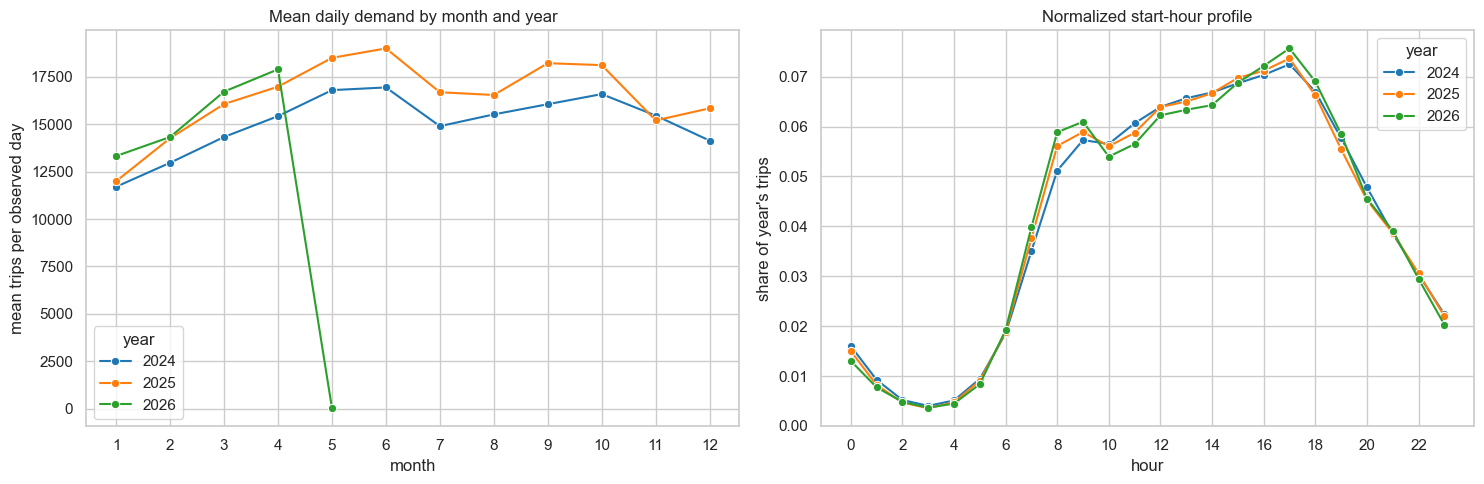

In [17]:
monthly_year = con.sql("""
WITH daily AS (
    SELECT YEAR(trip_start_timestamp)::INTEGER AS year, MONTH(trip_start_timestamp)::INTEGER AS month,
           CAST(trip_start_timestamp AS DATE) AS date, COUNT(*) AS trips
    FROM trips GROUP BY 1, 2, 3
)
SELECT year, month, AVG(trips) AS mean_daily_trips FROM daily GROUP BY 1, 2 ORDER BY 1, 2
""").df()
hour_year = con.sql("""
SELECT YEAR(trip_start_timestamp)::INTEGER AS year,
       EXTRACT(hour FROM trip_start_timestamp)::INTEGER AS hour, COUNT(*) AS trips
FROM trips GROUP BY 1, 2 ORDER BY 1, 2
""").df()
hour_year["share"] = hour_year.trips / hour_year.groupby("year").trips.transform("sum")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.lineplot(data=monthly_year, x="month", y="mean_daily_trips", hue="year", marker="o", palette="tab10", ax=axes[0])
axes[0].set(title="Mean daily demand by month and year", xlabel="month", ylabel="mean trips per observed day", xticks=range(1, 13))
sns.lineplot(data=hour_year, x="hour", y="share", hue="year", marker="o", palette="tab10", ax=axes[1])
axes[1].set(title="Normalized start-hour profile", xlabel="hour", ylabel="share of year's trips", xticks=range(0, 24, 2))
plt.tight_layout(); plt.show()

In [18]:
def jensen_shannon_distance(p, q):
    p, q = np.asarray(p, dtype=float), np.asarray(q, dtype=float)
    p, q = p / p.sum(), q / q.sum()
    m = 0.5 * (p + q)
    def kl(a, b):
        mask = a > 0
        return np.sum(a[mask] * np.log2(a[mask] / b[mask]))
    return np.sqrt(0.5 * kl(p, m) + 0.5 * kl(q, m))

hour_matrix = hour_year.pivot(index="hour", columns="year", values="trips").fillna(0)
spatial_year = con.sql("""
SELECT YEAR(trip_start_timestamp)::INTEGER AS year, pickup_h3_cell AS h3_cell, COUNT(*) AS trips
FROM trips WHERE pickup_h3_cell IS NOT NULL GROUP BY 1, 2
""").df()
spatial_matrix = spatial_year.pivot(index="h3_cell", columns="year", values="trips").fillna(0)

distance_rows = []
for first, second in [(2024, 2025), (2024, 2026), (2025, 2026)]:
    distance_rows.append({
        "comparison": f"{first} vs {second}",
        "hourly_profile_JS_distance": jensen_shannon_distance(hour_matrix[first], hour_matrix[second]),
        "spatial_H3_r8_JS_distance": jensen_shannon_distance(spatial_matrix[first], spatial_matrix[second]),
    })
profile_distances = pd.DataFrame(distance_rows).set_index("comparison")
display(profile_distances.round(4))

relative_metrics = year_summary.set_index("year")[["trips_per_active_day", "mean_miles", "mean_minutes", "mean_fare", "mean_total"]]
relative_change = 100 * relative_metrics.pct_change()
display(relative_change.round(2).rename_axis("year vs previous year (%)"))

,hourly_profile_JS_distance,spatial_H3_r8_JS_distance
comparison,,
2024 vs 2025,0.0158,0.0641
2024 vs 2026,0.0279,0.1223
2025 vs 2026,0.0171,0.0684


,trips_per_active_day,mean_miles,mean_minutes,mean_fare,mean_total
year vs previous year (%),,,,,
2024,NaN,NaN,NaN,NaN,NaN
2025,9.21,-8.37,-6.94,-6.21,-7.42
2026,-6.13,-12.13,-11.75,-8.60,-8.80


### Modeling recommendation

Do not pick a training year from raw totals, 2026 is partial and seasonally truncated. The normalized tables and Jensen Shannon distances above are the better basis. Even where the hour of day shapes look similar, shifts in demand level, fares, trip characteristics or spatial shares are real concept drift that a deployed model should learn and that validation should test.

Our suggestion: train on 2024 plus the earlier part of 2025, tune and validate on a later contiguous block of 2025, and keep 2026 untouched as a forward in time holdout. Give the model calendar, weather, spatial unit and trend features instead of letting it memorize timestamps.

If compute limits force a single year, 2025 is the best candidate as the most recent complete year. It is still a compromise: seasonal coverage is fine, but year to year stability can no longer be tested and training data is thrown away. A useful sensitivity experiment is to compare a model trained only on 2025 with the recommended variant on the identical 2026 holdout.

## 8. Interpretation and possible reasons

Why do the patterns look the way they do? For time of day, commuting, airport schedules, nightlife, weather and major events are plausible mechanisms behind morning, evening and late-night patterns. The raw hourly profiles alone cannot identify those mechanisms. The OD-and-distance-controlled comparison tests whether the duration pattern remains within more comparable journeys; even if it does, the result is consistent with a time-of-day traffic effect rather than causal proof of congestion. Fares can also rise when airport and cross-city journeys make up a larger share of demand. For temporal aggregation, 15 minute bins expose short surges but are noisy and suffer from the timestamp rounding, while four hour and daily bins are stable but hide peak timing; hourly bins are a defensible middle ground for this data.

On the spatial side the usual MAUP logic applies: coarse H3 cells pool hot and cold locations, which raises counts and smooths extremes, fine cells reveal concentration but get unstable. Census tracts vary in size and follow population boundaries, H3 cells are uniform but ignore neighborhoods and infrastructure. The concentration downtown and at the airports fits dense employment, hotels, rail stations, entertainment and the airports themselves. The repeated privacy centroids create artificial point clusters, so H3 resolution 9 partitions released centroids rather than locating street level hotspots.

Idle time is an operational proxy, not vacant taxi telemetry: dense central and airport zones shorten search time, while repositioning, breaks, shift boundaries, missing trips and the 15 minute rounding stretch or distort observed gaps. Finally the data quality rule we apply throughout: use `trip_seconds` for duration, keep equal start and end timestamps when `trip_seconds` is valid, and drop records with missing or implausible durations or an end before the start. The silver and gold layers already exclude all 100 raw cases of the latter.